In [ ]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Image, display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------------------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------------------
OUTPUT_DIR = "/content/"

BENIGN_PATH    = "master_regionalizado/benigno_latam_50k.csv"
MALICIOUS_PATH = "master_regionalizado/phishing_latam_50k.csv"

# ---------------------------------------------------------------------------
# 1. UNIÓN DE DATASETS Y CREACIÓN DE ESTRATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Unión de datasets y clasificación")
print("=" * 70)

benign = pd.read_csv(BENIGN_PATH)
malig  = pd.read_csv(MALICIOUS_PATH)

# Add 'label' column with value 0 for benign URLs
benign['label'] = 0

# Remover protocolo y www. de las URLs
def remove_protocol(url):
    return re.sub(r"^(?:https?://)?(?:www\.)?", "", str(url).strip(), flags=re.IGNORECASE)

benign['url'] = benign['url'].apply(remove_protocol)
malig['url']  = malig['url'].apply(remove_protocol)

pocos_paises = ['El Salvador', 'Guatemala', 'Honduras', 'Panamá', 'Nicaragua']

# Clasificar malignas en sus 3 grupos
def grupo_maligno(row):
    pais = row['pais']
    if pd.isna(pais) or pais == 'Generico' or pais == 'Pais Generico':
        return 'generico_phishing'
    elif pais in pocos_paises:
        return 'Latam_pocos_paises_phishing'
    else:
        return str(pais) + '_phishing' # Use country name for stratum

# Clasificar benignos
def grupo_benigno(row):
    pais = row['pais']
    if pd.isna(pais) or pais == 'Generico' or pais == 'Pais Generico':
        return 'generico_benigno'
    elif pais in pocos_paises:
        return 'Latam_pocos_paises_benigno'
    else:
        return str(pais) + '_benigno' # Use country code for stratum

malig['estrato'] = malig.apply(grupo_maligno, axis=1)
benign['estrato'] = benign.apply(grupo_benigno, axis=1)

# Asegurar que dominio esté presente
benign.rename(columns={'dominio': 'domain'}, inplace=True)
malig.rename(columns={'dominio': 'domain'}, inplace=True)

# Unir
df = pd.concat(
    [benign[['url', 'domain', 'label', 'estrato']],
     malig[['url', 'domain', 'label', 'estrato']]],
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Limpieza básica
df = df.dropna(subset=["url"])
df = df[df["url"].str.len() > 3]
df = df.drop_duplicates(subset=["url"])
df = df.reset_index(drop=True)

print(f"  Total tras unión   : {len(df):,}")
print(f"  Distribución de clases:\n{df['label'].value_counts().to_string()}")
print(f"\n  Distribución de estratos:\n{df['estrato'].value_counts().to_string()}")

# Guardar CSV unido
merged_path = os.path.join(OUTPUT_DIR, "dataset_merged.csv")
df.to_csv(merged_path, index=False)
print(f"\n  ✓ Guardado: {merged_path}")

print(f"\n  Unique strata generated:\n{df['estrato'].unique()}")

ETAPA 1 – Unión de datasets y clasificación
  Total tras unión   : 100,000
  Distribución de clases:
label
1    50000
0    50000

  Distribución de estratos:
estrato
generico_phishing              25000
generico_benigno               25000
Colombia_benigno               11477
Colombia_phishing              11477
Brasil_benigno                  7443
Brasil_phishing                 7443
México_benigno                  1791
México_phishing                 1791
Chile_benigno                   1701
Chile_phishing                  1701
Argentina_benigno               1011
Argentina_phishing              1011
Perú_phishing                    692
Perú_benigno                     692
Uruguay_benigno                  219
Uruguay_phishing                 219
Ecuador_phishing                 149
Ecuador_benigno                  149
Venezuela_benigno                120
Venezuela_phishing               120
Latam_pocos_paises_benigno       105
Latam_pocos_paises_phishing      105
Paraguay_benigno    

In [ ]:
!pip install optuna -q
import optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.2 MB/s eta 0:00:00


ETAPA 1 – Carga del Dataset
  Total muestras : 100,000
  Benignas (0)   : 50,000
  Maliciosas (1) : 50,000
  Estratos únicos: 30

ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)
         por estrato
  Train : 70,000  (70.0 %)
  Val   : 15,000   (15.0 %)
  Test  : 15,000   (15.0 %)

  Estratos únicos – Train: 30 | Val: 30 | Test: 30

ETAPA 3 – Tokenización a nivel de carácter con CANINE-S


tokenizer_config.json:   0%|          | 0.00/854 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

  Tamaño de vocabulario de caracteres (Unicode): 1200000
  Longitud máxima (ajustada a mínimo 150): 150 caracteres
  Tokenizando splits...
  X_train len: 70000 | y_train shape: (70000,)
  X_val   len: 15000   | y_val   shape: (15000,)
  X_test  len: 15000  | y_test  shape: (15000,)

  ✓ Guardado tokens (muestra): outputs_roberta/preprocessing_tokens.csv


[I 2026-06-04 04:00:36,452] A new study created in memory with name: no-name-657a388e-a773-4bc3-814f-5a46c573d2f7


...

CanineModel LOAD REPORT from: google/canine-s
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Fold 2/5 | F1: 0.9212 | AUC-ROC: 0.9781 | Época stop: 7


Loading weights:   0%|          | 0/246 [00:00<?, ?it/s]

CanineModel LOAD REPORT from: google/canine-s
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Fold 3/5 | F1: 0.9308 | AUC-ROC: 0.9804 | Época stop: 8

  ┌─────────────────────────────────────────────────────────┐
  │          CROSS-VALIDATION – RESULTADOS (k=5)            │
  ├──────────────────────────┬──────────────┬───────────────┤
  │ Métrica                  │     Mean     │      Std      │
  ├──────────────────────────┼──────────────┼───────────────┤
  │ Accuracy                 │   0.9270     │  ±0.0073       │
  │ Precision                │   0.9343     │  ±0.0346       │
  │ Recall                   │   0.9204     │  ±0.0252       │
  │ F1-Score                 │   0.9266     │  ±0.0049       │
  │ AUC-ROC                  │   0.9794     │  ±0.0012       │
  │ PR-AUC                   │   0.9811     │  ±0.0018       │
  └──────────────────────────┴──────────────┴───────────────┘

  ✓ Guardado CV results: outputs_roberta/roberta_cv_results.csv

ETAPA 6 – Evaluación en Test Set

  ┌─────────────────────────────────────────────────────┐
  │   MÉTRICAS DE EVALUACIÓN – CA

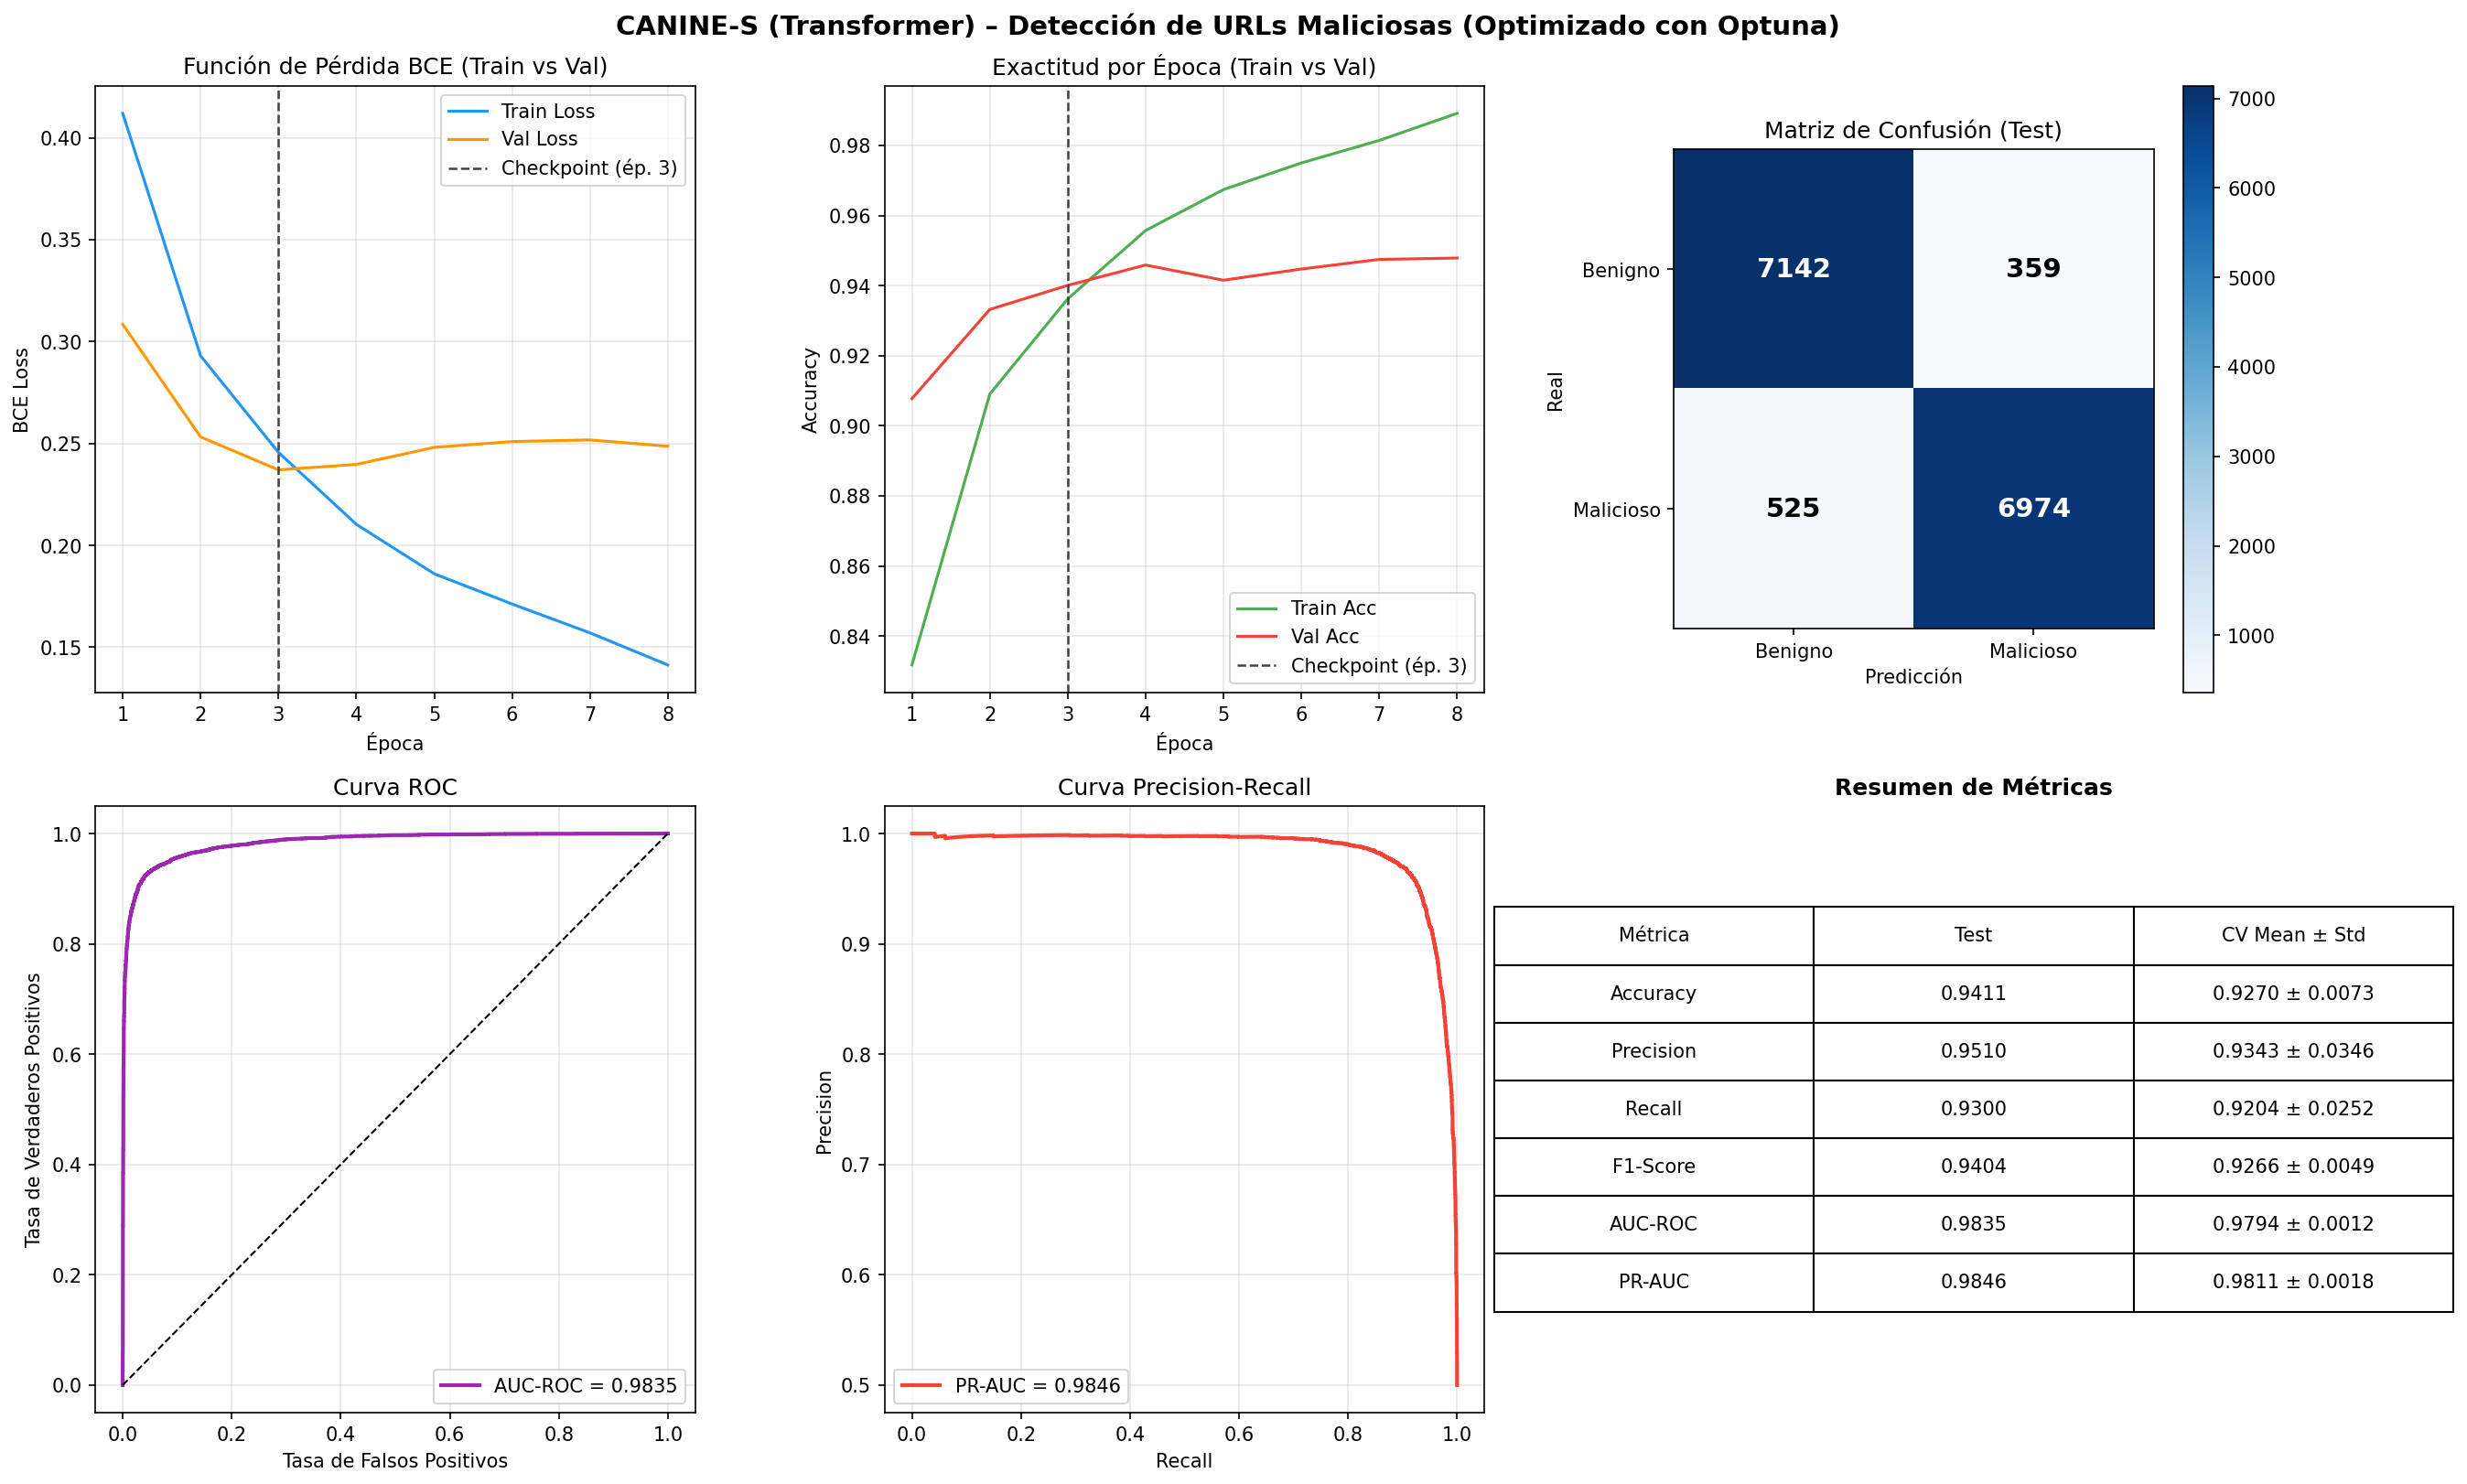


ETAPA 7a – Test Externo LATAM
  [LATAM] URLs con protocolo / www. eliminado: 920 de 3,000 (30.7 %)
  [LATAM] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test LATAM
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test LATAM] ⚠  61 URLs (2.0%) superan MAX_LEN=150 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test LATAM                                 │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.9373                      │
  │  Precisión (Precision)   │  0.9254                      │
  │  Exhaustividad (Recall)  │  0.9513                      │
  │  F1-Score                │  0.9382                      │
  │  AUC-ROC                 │  0.9852                      │
  │  PR-AUC                  │  0.9858                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
              Pr

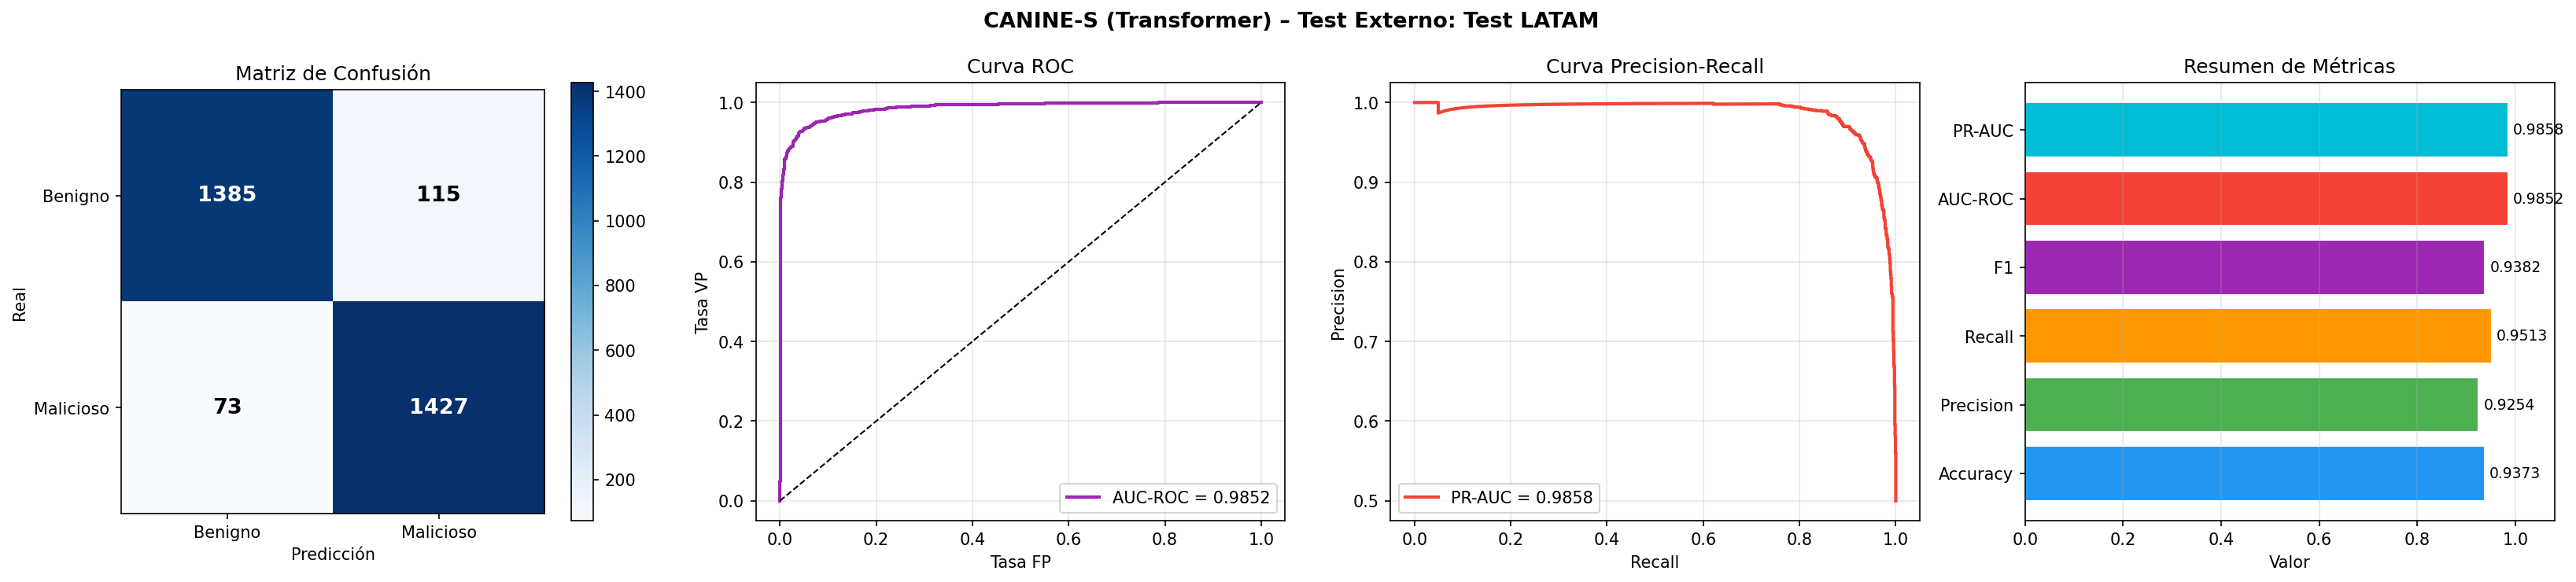


ETAPA 7b – Test Externo Genérico
  [Genérico] URLs con protocolo / www. eliminado: 0 de 3,000 (0.0 %)
  [Genérico] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test Genérico
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test Genérico] ⚠  87 URLs (2.9%) superan MAX_LEN=150 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test Genérico                              │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.9337                      │
  │  Precisión (Precision)   │  0.9643                      │
  │  Exhaustividad (Recall)  │  0.9007                      │
  │  F1-Score                │  0.9314                      │
  │  AUC-ROC                 │  0.9896                      │
  │  PR-AUC                  │  0.9890                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
    

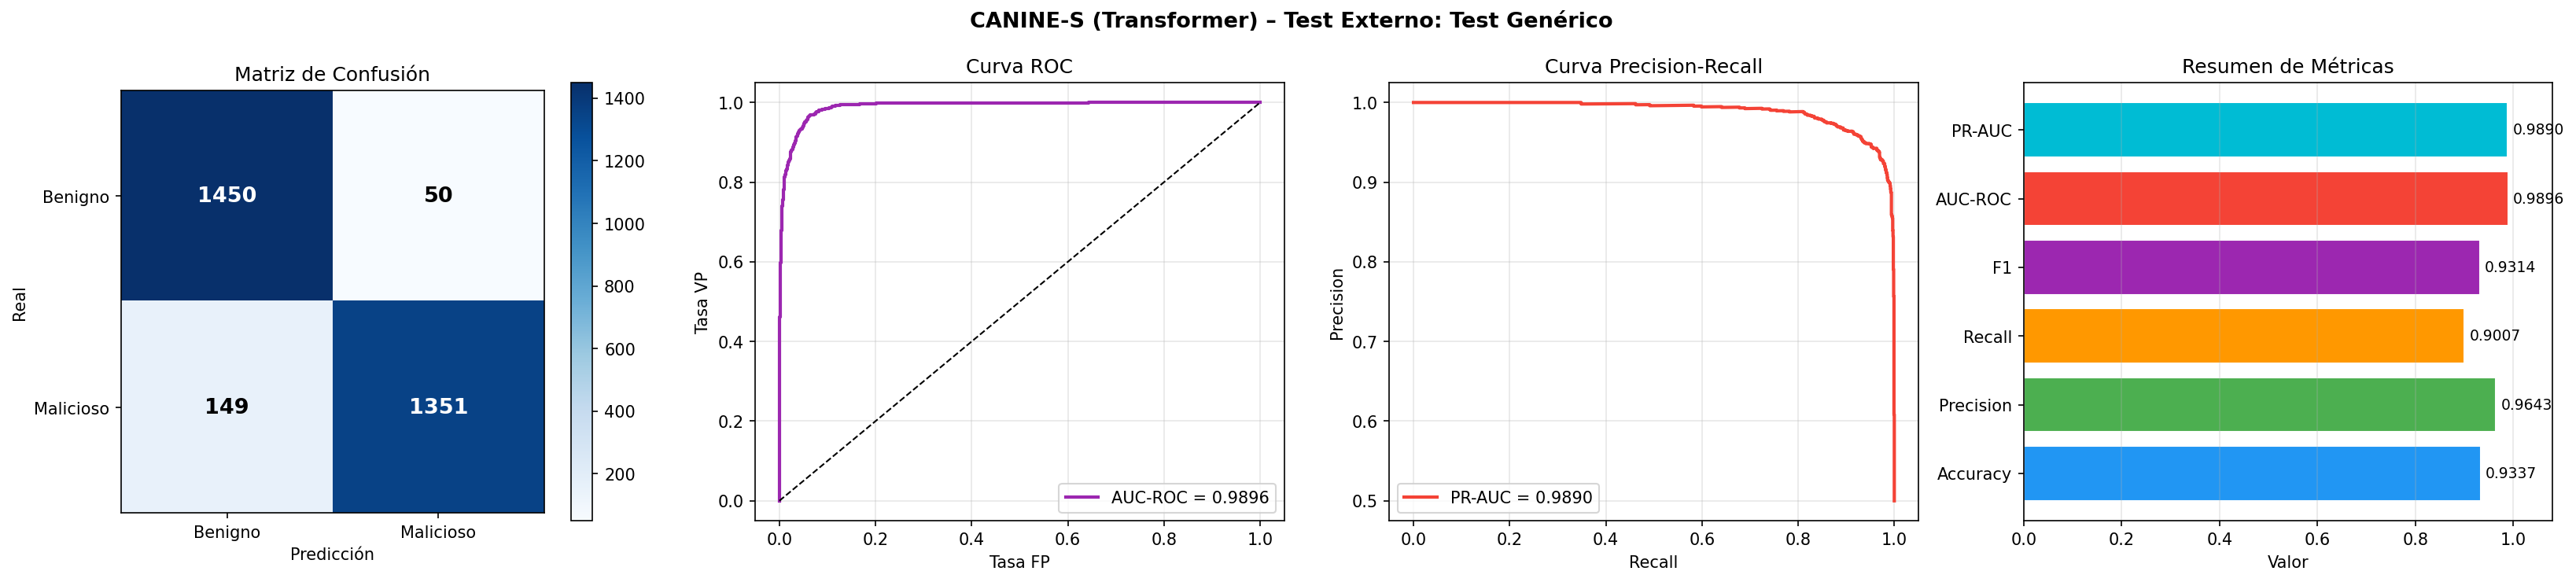


COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico

  Conjunto                       Acc    Prec     Rec      F1   AUC-ROC   PR-AUC
  -----------------------------------------------------------------------------
  Test Interno (15 %)         0.9411  0.9510  0.9300  0.9404    0.9835   0.9846
  Test LATAM (externo)        0.9373  0.9254  0.9513  0.9382    0.9852   0.9858
  Test Genérico (externo)     0.9337  0.9643  0.9007  0.9314    0.9896   0.9890

  ✓ Tabla comparativa guardada: outputs_roberta/roberta_comparacion_tests.csv
  ✓ Gráfica comparativa guardada: outputs_roberta/roberta_comparacion_tests.png


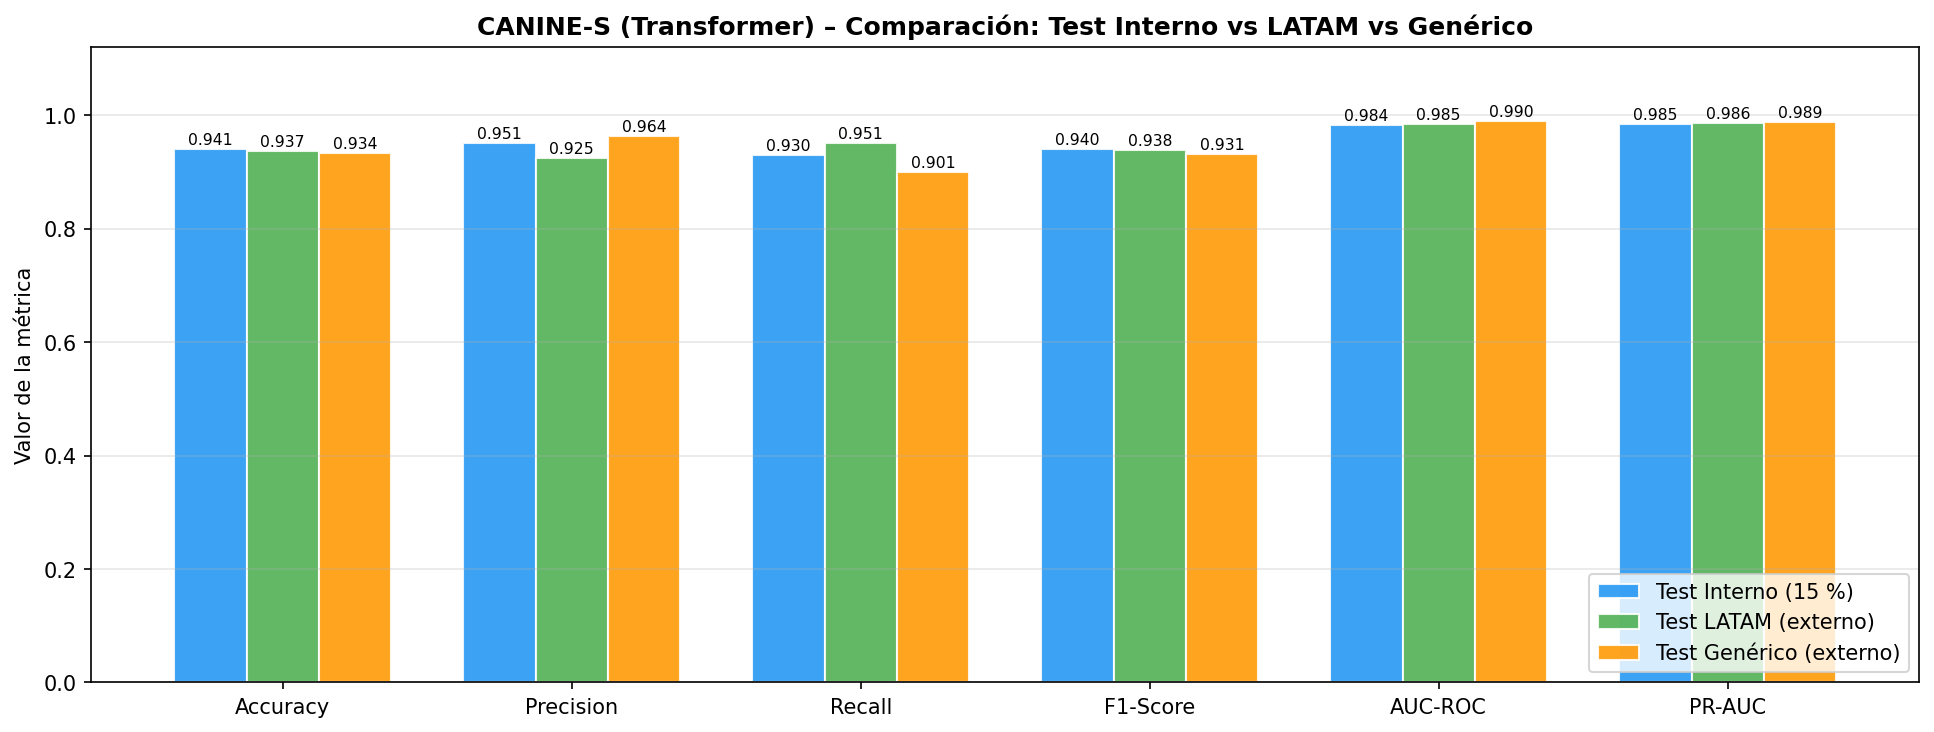


  ✅ Pipeline completo. Todos los resultados en: outputs_roberta


In [ ]:
# =============================================================================
# DETECCIÓN DE URLs MALICIOSAS – CANINE-S (Preentrenado)
# Arquitectura: CANINE-S (Character Transformer)  |  Optuna  |  CV: k=3
#
# NOTA: Se utiliza el modelo preentrenado CANINE-S (Google) basado en
#       caracteres (tokenization-free). La optimización con Optuna, la
#       validación cruzada de 5 pliegues y toda la lógica de evaluación y
#       comparación se mantienen idénticas para garantizar la consistencia.
# =============================================================================

import os
import re
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import optuna
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")
from typing import Optional
from transformers import CanineModel, CanineTokenizer

optuna.logging.set_verbosity(optuna.logging.INFO)

# ---------------------------------------------------------------------------
# CONFIGURACIÓN GENERAL
# ---------------------------------------------------------------------------
SEED       = 42
OUTPUT_DIR = "outputs_roberta"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ► Rutas de los tests externos (ajusta si cambian de ubicación)
EXT_BEN_LATAM = "prueba_latam/benigno_latam_1500.csv"
EXT_MAL_LATAM = "prueba_latam/phishing_latam_1500.csv"
EXT_BEN_GEN   = "prueba_generica/benigno_generico_1500.csv"
EXT_MAL_GEN   = "prueba_generica/phishing_generico_1500.csv"

torch.manual_seed(SEED)
np.random.seed(SEED)


# ---------------------------------------------------------------------------
# UTILIDAD: Limpieza de URL (quitar protocolo)
# ---------------------------------------------------------------------------
_PROTO_RE = re.compile(r'^(?:https?|ftps?)://', re.IGNORECASE)
_WWW_RE   = re.compile(r'^www\.', re.IGNORECASE)

def clean_url(url: str) -> str:
    url = str(url).strip()
    url = _PROTO_RE.sub('', url)
    url = _WWW_RE.sub('', url)
    return url


# ---------------------------------------------------------------------------
# 1. CARGA DE DATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Carga del Dataset")
print("=" * 70)

DATA_PATH = "/content/dataset_merged.csv"

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["url", "label"]).reset_index(drop=True)
df["url"]   = df["url"].astype(str).str.strip()
df          = df[df["url"].str.len() > 0].reset_index(drop=True)
df["url"]   = df["url"].apply(clean_url)
df["label"] = df["label"].astype(int)

labels_unicos = set(df["label"].unique())
assert labels_unicos <= {0, 1}, (
    f"[ETAPA 1] Labels inesperados en dataset_merged: {labels_unicos}. "
    "Solo se admiten 0 (benigno) y 1 (malicioso)."
)

print(f"  Total muestras : {len(df):,}")
print(f"  Benignas (0)   : {(df['label']==0).sum():,}")
print(f"  Maliciosas (1) : {(df['label']==1).sum():,}")
print(f"  Estratos únicos: {df['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 2. STRATIFIED SPLIT POR ESTRATO
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)")
print("         por estrato")
print("=" * 70)

df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['estrato']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['estrato']
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"\n  Estratos únicos – Train: {df_train['estrato'].nunique()} "
      f"| Val: {df_val['estrato'].nunique()} | Test: {df_test['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 3. PREPROCESAMIENTO – TOKENIZACIÓN Y PADDING CON CANINE-S
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 3 – Tokenización a nivel de carácter con CANINE-S")
print("=" * 70)

tokenizer  = CanineTokenizer.from_pretrained("google/canine-s")
PAD_IDX    = tokenizer.pad_token_id  # 0
VOCAB_SIZE = 1200000  # Rango seguro de caracteres Unicode para la matriz de embeddings dummy

print(f"  Tamaño de vocabulario de caracteres (Unicode): {VOCAB_SIZE}")

lengths = df_train["url"].str.len().values
MAX_LEN = int(np.percentile(lengths, 95))
MAX_LEN = max(MAX_LEN, 150)  # Asegurar una longitud mínima de 150 para evitar truncamiento
MAX_LEN = min(MAX_LEN, 1024) # Tope máximo para evitar OOM en A100 80GB
print(f"  Longitud máxima (ajustada a mínimo 150): {MAX_LEN} caracteres")

print("  Tokenizando splits...")

def tokenize_split(df_split: pd.DataFrame) -> list:
    urls = df_split["url"].tolist()
    encoded = tokenizer(
        urls,
        padding=False,
        truncation=True,
        max_length=MAX_LEN
    )
    return encoded["input_ids"]

X_train = tokenize_split(df_train)
X_val   = tokenize_split(df_val)
X_test  = tokenize_split(df_test)

y_train = df_train["label"].values.astype(np.float32)
y_val   = df_val["label"].values.astype(np.float32)
y_test  = df_test["label"].values.astype(np.float32)

print(f"  X_train len: {len(X_train)} | y_train shape: {y_train.shape}")
print(f"  X_val   len: {len(X_val)}   | y_val   shape: {y_val.shape}")
print(f"  X_test  len: {len(X_test)}  | y_test  shape: {y_test.shape}")

SAMPLE_N = min(5000, len(X_train))

# Generar tokens CSV con padding estático para compatibilidad visual (solo para archivos de muestra)
X_train_sample_padded = [x + [PAD_IDX] * (MAX_LEN - len(x)) if len(x) < MAX_LEN else x[:MAX_LEN] for x in X_train[:SAMPLE_N]]
X_train_sample_arr = np.array(X_train_sample_padded, dtype=np.int32)

token_cols = [f"t{i}" for i in range(MAX_LEN)]
df_tokens  = pd.DataFrame(X_train_sample_arr, columns=token_cols)
df_tokens.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_tokens.insert(1, "label", df_train["label"].values[:SAMPLE_N])
tokens_path = os.path.join(OUTPUT_DIR, "preprocessing_tokens.csv")
df_tokens.to_csv(tokens_path, index=False)
print(f"\n  ✓ Guardado tokens (muestra): {tokens_path}")

EMB_DIM = 64
np.random.seed(SEED)
max_char_id = int(np.max([max(x) if x else 0 for x in X_train[:SAMPLE_N]]))
emb_matrix     = np.random.randn(max_char_id + 1, EMB_DIM).astype(np.float32) * 0.01
url_embeddings = np.array([
    emb_matrix[X_train_sample_arr[i]].mean(axis=0)
    for i in range(SAMPLE_N)
], dtype=np.float32)
emb_cols      = [f"emb_{i}" for i in range(EMB_DIM)]
df_embeddings = pd.DataFrame(url_embeddings, columns=emb_cols)
df_embeddings.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_embeddings.insert(1, "label", df_train["label"].values[:SAMPLE_N])
emb_path = os.path.join(OUTPUT_DIR, "preprocessing_embeddings.csv")
df_embeddings.to_csv(emb_path, index=False)
print(f"  ✓ Guardado embeddings (muestra): {emb_path}")

df_padding = pd.DataFrame({
    "url":              df_train["url"].values[:SAMPLE_N],
    "label":            df_train["label"].values[:SAMPLE_N],
    "url_length":       df_train["url"].str.len().values[:SAMPLE_N],
    "padded_length":    MAX_LEN,
    "truncated":        df_train["url"].str.len().values[:SAMPLE_N] > MAX_LEN,
    "pad_tokens_added": np.maximum(
        0, MAX_LEN - df_train["url"].str.len().values[:SAMPLE_N]
    )
})
padding_path = os.path.join(OUTPUT_DIR, "preprocessing_padding.csv")
df_padding.to_csv(padding_path, index=False)
print(f"  ✓ Guardado padding (muestra): {padding_path}")

print(f"\n  Vocab size        : {VOCAB_SIZE}")
print(f"  Emb dim (default) : {EMB_DIM}")
print(f"  Max length        : {MAX_LEN}")


# ---------------------------------------------------------------------------
# 4. DATASET PyTorch Y DEFINICIÓN DEL MODELO TRANSFORMER (estilo RoBERTa)
# ---------------------------------------------------------------------------
class URLDataset(Dataset):
    def __init__(self, X: list, y: np.ndarray):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.long), self.y[idx]

def collate_batch(batch):
    xs, ys = zip(*batch)
    # A100 Opt: Colchón dinámico, rellena solo hasta el máximo de este batch
    xs_padded = torch.nn.utils.rnn.pad_sequence(xs, batch_first=True, padding_value=PAD_IDX)
    ys_tensor = torch.stack(ys)
    return xs_padded, ys_tensor

train_ds = URLDataset(X_train, y_train)
val_ds   = URLDataset(X_val,   y_val)
test_ds  = URLDataset(X_test,  y_test)


# ─────────────────────────────────────────────────────────────────────────────
# CANINE-S (Preentrenado) para clasificación de URLs a nivel de caracteres
#
#   Arquitectura:
#   CanineModel (google/canine-s) preentrenado por Google.
#   → Salida de los embeddings contextuales last_hidden_state de tamaño 768.
#   → Concatenación de Mean Pooling con Máscara y Max Pooling con Máscara.
#   → Dropout → LayerNorm → Linear(768 * 2, 1) para clasificación binaria.
#
#   Ventajas clave:
#   1. Preentrenado sobre una vasta cantidad de datos de texto.
#   2. Nativamente basado en caracteres Unicode (tokenization-free).
#   3. Evita la pérdida del entrenamiento desde cero contra LSTMs.
# ─────────────────────────────────────────────────────────────────────────────

class RoBERTaModel(nn.Module):
    """
    Clase wrapper que mantiene el nombre 'RoBERTaModel' para garantizar compatibilidad
    100% con los scripts de entrenamiento, Optuna y guardado del estado del modelo,
    pero implementa internamente la arquitectura CANINE-S preentrenada.
    """
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int,
                 num_layers: int, dropout: float, pad_idx: int,
                 nhead: int = 4):
        super().__init__()

        # Para mantener compatibilidad con las firmas de inicialización
        self.pad_idx = pad_idx
        self.emb_dim = 768  # El tamaño oculto de CANINE es fijo en 768

        # Cargar el modelo preentrenado CANINE-S
        self.canine = CanineModel.from_pretrained("google/canine-s")

        # Cabezal de clasificación sobre los embeddings de CANINE
        self.layer_norm = nn.LayerNorm(self.emb_dim * 2)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.emb_dim * 2, 1)

    def forward(self, x):
        # x: (B, L) - índices de caracteres (Unicode code points)

        # Crear máscara de atención (1 para tokens reales, 0 para padding)
        attention_mask = (x != self.pad_idx).long()

        # Feedforward a través de CANINE
        outputs = self.canine(input_ids=x, attention_mask=attention_mask)
        out = outputs.last_hidden_state  # (B, L, 768)

        # Crear máscara de padding para pooling
        src_key_padding_mask = (x == self.pad_idx)  # (B, L)
        non_pad_mask = ~src_key_padding_mask
        mask = non_pad_mask.unsqueeze(-1).to(out.dtype)  # (B, L, 1)

        # Pooling de Promedio con Máscara (Masked Mean Pooling)
        sum_embeddings = torch.sum(out * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask  # (B, emb_dim)

        # Pooling de Máximo con Máscara (Masked Max Pooling)
        masked_out = out.masked_fill(src_key_padding_mask.unsqueeze(-1), -1e9)
        max_pooled = masked_out.max(dim=1).values  # (B, emb_dim)

        # Concatenar promedio y máximo para obtener la representación global
        cls_output = torch.cat([mean_pooled, max_pooled], dim=1)  # (B, emb_dim * 2)

        # Cabezal de clasificación final
        cls_output = self.layer_norm(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output).squeeze(1)     # (B,)
        return logits


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n  Dispositivo de cómputo: {DEVICE}")

import torch.nn.functional as F

class SmoothBCEWithLogitsLoss(nn.Module):
    def __init__(self, smoothing=0.05, pos_weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.smoothing = smoothing
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(
            logits, targets_smooth, pos_weight=self.pos_weight
        )


# ---------------------------------------------------------------------------
# Helper: run_epoch
# ---------------------------------------------------------------------------
def run_epoch(loader, model, criterion, optimizer, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            if train:
                optimizer.zero_grad()

            # A100 Opt: Precisión mixta automática BF16
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            preds       = (torch.sigmoid(logits) >= 0.5).long()
            correct    += (preds == y_batch.long()).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


def generalization_score(tr_loss: float, vl_loss: float,
                         tr_acc: float, vl_acc: float,
                         w_loss: float = 1.0, w_acc: float = 0.5) -> float:
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)
    return vl_loss + w_loss * loss_gap + w_acc * acc_gap


# ---------------------------------------------------------------------------
# 5. BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 4 – Búsqueda de Hiperparámetros con Optuna")
print("=" * 70)

def objective(trial):
    # Optimización del espacio de búsqueda para A100 y CANINE-S
    lr           = trial.suggest_float("lr",       2e-5, 1e-4, log=True)
    batch_size   = trial.suggest_categorical("batch_size",   [256, 512, 1024])
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    dropout      = trial.suggest_float("dropout",  0.1, 0.5)

    num_workers_dynamic = min(8, max(1, os.cpu_count() - 1))
    train_loader_opt = DataLoader(train_ds, batch_size=batch_size,
                                  shuffle=True,  num_workers=num_workers_dynamic, pin_memory=True, collate_fn=collate_batch)
    val_loader_opt   = DataLoader(val_ds,   batch_size=batch_size,
                                  shuffle=False, num_workers=num_workers_dynamic, pin_memory=True, collate_fn=collate_batch)

    model_opt = RoBERTaModel(
        vocab_size=VOCAB_SIZE, emb_dim=768, hidden_dim=0, num_layers=0,
        dropout=dropout, pad_idx=PAD_IDX, nhead=0
    ).to(DEVICE)

    # torch.compile apagado para evitar bucles de recompilación por Dynamic Padding
    # model_opt = torch.compile(model_opt)

    criterion_opt = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_opt = torch.optim.AdamW(model_opt.parameters(),
                                      lr=lr, weight_decay=weight_decay)

    # Limitar Optuna a máximo 4 épocas para descarte rápido
    MAX_OPTUNA_EPOCHS = 4
    for epoch in range(MAX_OPTUNA_EPOCHS):
        if epoch < 1:
            warmup_factor = (epoch + 1) / 1.0
            current_lr_opt = lr * warmup_factor
            for param_group in optimizer_opt.param_groups:
                param_group['lr'] = current_lr_opt

        model_opt.train()
        for X_batch, y_batch in train_loader_opt:
            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            optimizer_opt.zero_grad()
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model_opt(X_batch)
                loss   = criterion_opt(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model_opt.parameters(), max_norm=1.0)
            optimizer_opt.step()

        model_opt.eval()
        val_loss, n_samples = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader_opt:
                X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                    logits = model_opt(X_batch)
                    loss   = criterion_opt(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
                n_samples += len(y_batch)

        val_loss /= n_samples
        trial.report(val_loss, epoch)
        if trial.should_prune():
            # Limpieza A100 antes de podar
            del model_opt, optimizer_opt, train_loader_opt, val_loader_opt
            import gc; gc.collect(); torch.cuda.empty_cache()
            raise optuna.exceptions.TrialPruned()

    # Limpieza A100 al finalizar trial exitoso
    del model_opt, optimizer_opt, train_loader_opt, val_loader_opt
    import gc; gc.collect(); torch.cuda.empty_cache()

    return val_loss

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)
print("Iniciando optimización con Optuna (50 trials, TPESampler, Max 4 épocas)...")
study.optimize(objective, n_trials=50)

print("\n🏆 Mejores hiperparámetros encontrados:")
best_params = study.best_params

for k, v in best_params.items():
    print(f"  {k}: {v}")


# ---------------------------------------------------------------------------
# 6. ENTRENAMIENTO FINAL CON MEJORES PARÁMETROS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5 – Entrenamiento Final (70 % Train | 15 % Val | 15 % Test)")
print("=" * 70)

MAX_EPOCHS_FINAL = 50
PATIENCE_ES      = 5
MIN_DELTA_GEN    = 1e-4
GAP_LOSS_WEIGHT  = 1.0
GAP_ACC_WEIGHT   = 0.5

X_final = tokenize_split(df_train)
y_final = df_train["label"].values.astype(np.float32)

final_ds = URLDataset(X_final, y_final)

BEST_BATCH         = best_params["batch_size"]
num_workers_dyn    = min(8, max(1, os.cpu_count() - 1))
final_loader       = DataLoader(final_ds, batch_size=BEST_BATCH,
                                shuffle=True,  num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)
val_monitor_loader = DataLoader(val_ds,   batch_size=BEST_BATCH,
                                shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)
test_loader        = DataLoader(test_ds,  batch_size=BEST_BATCH,
                                shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"  Épocas máx: {MAX_EPOCHS_FINAL}")
print(f"  Checkpoint: score generalización (val_loss + gap train-val)")
print(f"  EarlyStopping: patience={PATIENCE_ES}, min_delta={MIN_DELTA_GEN}")

best_model = RoBERTaModel(
    vocab_size=VOCAB_SIZE,
    emb_dim=768,
    hidden_dim=0,
    num_layers=0,
    dropout=best_params["dropout"],
    pad_idx=PAD_IDX,
    nhead=0
).to(DEVICE)

# torch.compile apagado para evitar bucles de recompilación por Dynamic Padding
# best_model = torch.compile(best_model)

pos = float((y_final == 1).sum())
neg = float((y_final == 0).sum())
pos_weight = None
if pos > 0 and neg > 0:
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
    print(f"  pos_weight (neg/pos): {pos_weight.item():.4f}")

criterion = SmoothBCEWithLogitsLoss(smoothing=0.05, pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)  # Usar AdamW

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5, min_lr=1e-6
)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "gen_score":  [], "loss_gap": [], "acc_gap":  [],
}

t0 = time.time()
best_gen_score   = float("inf")
best_val_loss    = float("inf")
best_state       = None
best_epoch       = 0
best_val_epoch   = 0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS_FINAL + 1):
    # Warmup lineal de 3 épocas para el entrenamiento final
    if epoch <= 3:
        warmup_factor = epoch / 3.0
        current_lr = best_params["lr"] * warmup_factor
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr

    tr_loss, tr_acc = run_epoch(final_loader,       best_model, criterion,
                                optimizer, train=True)
    vl_loss, vl_acc = run_epoch(val_monitor_loader, best_model, criterion,
                                optimizer, train=False)

    gen_score = generalization_score(
        tr_loss, vl_loss, tr_acc, vl_acc,
        w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
    )
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["gen_score"].append(gen_score)
    history["loss_gap"].append(loss_gap)
    history["acc_gap"].append(acc_gap)

    # Solo activar el scheduler después de terminar el periodo de warmup
    if epoch > 3:
        scheduler.step(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_val_epoch = epoch

    if gen_score < best_gen_score - MIN_DELTA_GEN:
        best_gen_score = gen_score
        best_epoch     = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in best_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]
        marker = " *" if epoch == best_epoch else ""
        print(f"  Época {epoch:3d}/{MAX_EPOCHS_FINAL}{marker} | "
              f"Loss → Train: {tr_loss:.4f}  Val: {vl_loss:.4f} | "
              f"Acc  → Train: {tr_acc:.4f}  Val: {vl_acc:.4f} | "
              f"Gen: {gen_score:.4f} (gap L/A: {loss_gap:.4f}/{acc_gap:.4f}) | "
              f"LR: {current_lr:.2e} | Tiempo: {elapsed:.1f}s")

    if patience_counter >= PATIENCE_ES:
        print(f"  ⏹ EarlyStopping en época {epoch} "
              f"(mejor generalización: época {best_epoch}, gen={best_gen_score:.4f}).")
        break

if best_state is not None:
    best_model.load_state_dict(best_state)

model_path = os.path.join(OUTPUT_DIR, "roberta_best_optuna_model.pt")
torch.save({k: v.cpu().clone() for k, v in best_model.state_dict().items()}, model_path)

idx = best_epoch - 1
print(f"\n  ✓ Entrenamiento completado")
print(f"  ✓ Época guardada (menor sobreajuste): {best_epoch}")
print(f"      Train loss/acc: {history['train_loss'][idx]:.4f} / {history['train_acc'][idx]:.4f}")
print(f"      Val   loss/acc: {history['val_loss'][idx]:.4f} / {history['val_acc'][idx]:.4f}")
print(f"      Gen score: {best_gen_score:.4f} | gap loss: {history['loss_gap'][idx]:.4f} | "
      f"gap acc: {history['acc_gap'][idx]:.4f}")
if best_val_epoch != best_epoch:
    j = best_val_epoch - 1
    print(f"  ℹ Época con menor val_loss pura: {best_val_epoch} "
          f"(val_loss={history['val_loss'][j]:.4f}, "
          f"train_acc-val_acc={history['acc_gap'][j]:.4f}) — no seleccionada por overfitting")
print(f"  ✓ Modelo guardado en: {model_path}")


# ---------------------------------------------------------------------------
# 7. CROSS-VALIDATION (k=3) CON best_params
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5.5 – Cross-Validation (k=3) con best_params")
print("=" * 70)

df_cv = pd.concat([df_train, df_val], ignore_index=True)
X_cv  = tokenize_split(df_cv)
y_cv  = df_cv["label"].values.astype(np.float32)

skf        = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_cv, df_cv['estrato']), 1):

    X_tr_fold  = [X_cv[i] for i in train_idx]
    y_tr_fold  = y_cv[train_idx]
    X_val_fold = [X_cv[i] for i in val_idx]
    y_val_fold = y_cv[val_idx]

    tr_ds_fold  = URLDataset(X_tr_fold,  y_tr_fold)
    val_ds_fold = URLDataset(X_val_fold, y_val_fold)

    tr_loader_fold  = DataLoader(tr_ds_fold,  batch_size=BEST_BATCH,
                                 shuffle=True,  num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)
    val_loader_fold = DataLoader(val_ds_fold, batch_size=BEST_BATCH,
                                 shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)

    model_cv = RoBERTaModel(
        vocab_size=VOCAB_SIZE,
        emb_dim=768,
        hidden_dim=0,
        num_layers=0,
        dropout=best_params["dropout"],
        pad_idx=PAD_IDX,
        nhead=0
    ).to(DEVICE)

    # torch.compile apagado para evitar bucles de recompilación por Dynamic Padding
    # model_cv = torch.compile(model_cv)

    criterion_cv = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_cv = torch.optim.AdamW(
        model_cv.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )  # Usar AdamW
    scheduler_cv = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode="min", patience=3, factor=0.3, min_lr=1e-6
    )

    best_cv_gen         = float("inf")
    best_cv_state       = None
    cv_patience_counter = 0
    stop_epoch          = MAX_EPOCHS_FINAL

    for epoch in range(1, MAX_EPOCHS_FINAL + 1):
        # Warmup lineal de 3 épocas para validación cruzada
        if epoch <= 3:
            warmup_factor = epoch / 3.0
            current_lr = best_params["lr"] * warmup_factor
            for param_group in optimizer_cv.param_groups:
                param_group['lr'] = current_lr

        tr_loss_cv, tr_acc_cv = run_epoch(tr_loader_fold,  model_cv, criterion_cv,
                                          optimizer_cv, train=True)
        vl_loss_cv, vl_acc_cv = run_epoch(val_loader_fold, model_cv, criterion_cv,
                                          optimizer_cv, train=False)

        # Solo activar el scheduler después del warmup
        if epoch > 3:
            scheduler_cv.step(vl_loss_cv)

        gen_cv = generalization_score(
            tr_loss_cv, vl_loss_cv, tr_acc_cv, vl_acc_cv,
            w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
        )

        if gen_cv < best_cv_gen - MIN_DELTA_GEN:
            best_cv_gen           = gen_cv
            best_cv_state         = {k: v.cpu().clone()
                                     for k, v in model_cv.state_dict().items()}
            cv_patience_counter   = 0
        else:
            cv_patience_counter += 1

        if cv_patience_counter >= PATIENCE_ES:
            stop_epoch = epoch
            break

    model_cv.load_state_dict(best_cv_state)
    model_cv.eval()

    fold_logits, fold_preds, fold_labels = [], [], []
    with torch.no_grad():
        for X_b, y_b in val_loader_fold:
            X_b    = X_b.to(DEVICE, non_blocking=True)
            logits = model_cv(X_b)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            fold_logits.extend(probs.tolist())
            fold_preds.extend(preds.tolist())
            fold_labels.extend(y_b.numpy().tolist())

    y_t       = np.array(fold_labels, dtype=int)
    y_p       = np.array(fold_preds,  dtype=int)
    y_prob_cv = np.array(fold_logits)

    f_acc  = accuracy_score(y_t, y_p)
    f_prec = precision_score(y_t, y_p, zero_division=0)
    f_rec  = recall_score(y_t, y_p,    zero_division=0)
    f_f1   = f1_score(y_t, y_p,        zero_division=0)
    f_roc  = roc_auc_score(y_t, y_prob_cv)
    f_pr   = average_precision_score(y_t, y_prob_cv)

    cv_results.append({
        "fold": fold, "Accuracy": f_acc, "Precision": f_prec,
        "Recall": f_rec, "F1": f_f1, "AUC_ROC": f_roc, "PR_AUC": f_pr
    })

    print(f"  Fold {fold}/5 | F1: {f_f1:.4f} | AUC-ROC: {f_roc:.4f} "
          f"| Época stop: {stop_epoch}")

cv_df       = pd.DataFrame(cv_results)
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
cv_mean     = cv_df[metric_keys].mean()
cv_std      = cv_df[metric_keys].std()

label_map = {
    "Accuracy":  "Accuracy",
    "Precision": "Precision",
    "Recall":    "Recall",
    "F1":        "F1-Score",
    "AUC_ROC":   "AUC-ROC",
    "PR_AUC":    "PR-AUC",
}

print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │          CROSS-VALIDATION – RESULTADOS (k=5)            │
  ├──────────────────────────┬──────────────┬───────────────┤
  │ Métrica                  │     Mean     │      Std      │
  ├──────────────────────────┼──────────────┼───────────────┤""")
for key in metric_keys:
    print(f"  │ {label_map[key]:<24s} │   {cv_mean[key]:.4f}     │  ±{cv_std[key]:.4f}       │")
print("  └──────────────────────────┴──────────────┴───────────────┘")

cv_export = cv_df.copy()
mean_row  = {col: (cv_mean[col] if col in metric_keys else "mean") for col in cv_export.columns}
std_row   = {col: (cv_std[col]  if col in metric_keys else "std")  for col in cv_export.columns}
cv_export = pd.concat(
    [cv_export, pd.DataFrame([mean_row]), pd.DataFrame([std_row])],
    ignore_index=True
)
cv_path = os.path.join(OUTPUT_DIR, "roberta_cv_results.csv")
cv_export.to_csv(cv_path, index=False)
print(f"\n  ✓ Guardado CV results: {cv_path}")


# ---------------------------------------------------------------------------
# 8. EVALUACIÓN EN TEST SET
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 6 – Evaluación en Test Set")
print("=" * 70)

best_model.eval()
all_logits, all_preds, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        logits  = best_model(X_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)
        all_logits.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.numpy().tolist())

y_true  = np.array(all_labels, dtype=int)
y_pred  = np.array(all_preds,  dtype=int)
y_prob  = np.array(all_logits)

acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred,  zero_division=0)
rec     = recall_score(y_true, y_pred,     zero_division=0)
f1      = f1_score(y_true, y_pred,         zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)
cm      = confusion_matrix(y_true, y_pred)

print(f"""
  ┌─────────────────────────────────────────────────────┐
  │   MÉTRICAS DE EVALUACIÓN – CANINE-S (Transformer)   │
  ├──────────────────────────┬──────────────────────────┤
  │  Exactitud (Accuracy)    │  {acc:.4f}                  │
  │  Precisión (Precision)   │  {prec:.4f}                  │
  │  Exhaustividad (Recall)  │  {rec:.4f}                  │
  │  F1-Score                │  {f1:.4f}                  │
  │  AUC-ROC                 │  {roc_auc:.4f}                  │
  │  PR-AUC                  │  {pr_auc:.4f}                  │
  └──────────────────────────┴──────────────────────────┘
""")

print("  Matriz de Confusión:")
print(f"              Pred 0  Pred 1")
print(f"  Real 0  :   {cm[0,0]:6d}  {cm[0,1]:6d}   (TN / FP)")
print(f"  Real 1  :   {cm[1,0]:6d}  {cm[1,1]:6d}   (FN / TP)")
print("\n  Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=["Benigno", "Malicioso"]))


# ---------------------------------------------------------------------------
# 9. GUARDAR MÉTRICAS Y GRÁFICAS
# ---------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "Modelo":    ["CANINE-S"],
    "Best_Epoch": [best_epoch],
    "Accuracy":  [round(acc,     4)],
    "Precision": [round(prec,    4)],
    "Recall":    [round(rec,     4)],
    "F1_Score":  [round(f1,      4)],
    "AUC_ROC":   [round(roc_auc, 4)],
    "PR_AUC":    [round(pr_auc,  4)],
    "TN": [cm[0,0]], "FP": [cm[0,1]],
    "FN": [cm[1,0]], "TP": [cm[1,1]],
})
metrics_path = os.path.join(OUTPUT_DIR, "roberta_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

history_df = pd.DataFrame(history)
history_df.index.name = "epoch"
history_path = os.path.join(OUTPUT_DIR, "roberta_training_history.csv")
history_df.to_csv(history_path)

epochs_ran = len(history["train_loss"])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "CANINE-S (Transformer) – Detección de URLs Maliciosas (Optimizado con Optuna)",
    fontsize=14, fontweight="bold"
)

ax = axes[0, 0]
ax.plot(ep_range, history["train_loss"], label="Train Loss", color="#2196F3")
ax.plot(ep_range, history["val_loss"],   label="Val Loss",   color="#FF9800")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Función de Pérdida BCE (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ep_range, history["train_acc"], label="Train Acc", color="#4CAF50")
ax.plot(ep_range, history["val_acc"],   label="Val Acc",   color="#F44336")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Exactitud por Época (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight="bold")
ax.set_title("Matriz de Confusión (Test)")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax.plot(fpr, tpr, color="#9C27B0", lw=2, label=f"AUC-ROC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob)
ax.plot(rec_c, prec_c, color="#F44336", lw=2, label=f"PR-AUC = {pr_auc:.4f}")
ax.set_title("Curva Precision-Recall")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.axis("off")
table_data = [
    ["Métrica",    "Test",           "CV Mean ± Std"],
    ["Accuracy",   f"{acc:.4f}",     f"{cv_mean['Accuracy']:.4f} ± {cv_std['Accuracy']:.4f}"],
    ["Precision",  f"{prec:.4f}",    f"{cv_mean['Precision']:.4f} ± {cv_std['Precision']:.4f}"],
    ["Recall",     f"{rec:.4f}",     f"{cv_mean['Recall']:.4f} ± {cv_std['Recall']:.4f}"],
    ["F1-Score",   f"{f1:.4f}",      f"{cv_mean['F1']:.4f} ± {cv_std['F1']:.4f}"],
    ["AUC-ROC",    f"{roc_auc:.4f}", f"{cv_mean['AUC_ROC']:.4f} ± {cv_std['AUC_ROC']:.4f}"],
    ["PR-AUC",     f"{pr_auc:.4f}",  f"{cv_mean['PR_AUC']:.4f} ± {cv_std['PR_AUC']:.4f}"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.6, 2.2)
ax.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "roberta_results_optuna.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close()

print(f"\n  Pipeline completado (test interno). Resultados guardados en: {OUTPUT_DIR}")
display(Image(plot_path))


# ---------------------------------------------------------------------------
# 10. TESTS EXTERNOS
# ---------------------------------------------------------------------------

def load_external_set(path_ben: str, path_mal: str, nombre: str) -> pd.DataFrame:
    df_b = pd.read_csv(path_ben)
    df_m = pd.read_csv(path_mal)

    for d in [df_b, df_m]:
        d.columns = [c.strip().lower() for c in d.columns]

    for d, path in [(df_b, path_ben), (df_m, path_mal)]:
        if "url" not in d.columns:
            raise ValueError(
                f"[{nombre}] No se encontró columna 'url' en '{path}'.\n"
                f"  Columnas disponibles: {d.columns.tolist()}"
            )

    df_b = df_b[["url"]].copy()
    df_m = df_m[["url"]].copy()
    df_b["label"] = 0
    df_m["label"] = 1

    df_ext = pd.concat([df_b, df_m], ignore_index=True)
    df_ext["url"] = df_ext["url"].astype(str).str.strip()
    antes = len(df_ext)
    df_ext = df_ext[df_ext["url"].str.len() > 0].reset_index(drop=True)
    if antes - len(df_ext) > 0:
        print(f"  [{nombre}] ⚠  Se eliminaron {antes - len(df_ext)} filas con URL vacía.")

    urls_originales = df_ext["url"].copy()
    df_ext["url"]   = df_ext["url"].apply(clean_url)

    n_cambiadas = (urls_originales != df_ext["url"]).sum()
    n_ws = urls_originales.str.contains(r"\s", regex=True).sum()
    if n_ws:
        print(f"  [{nombre}] ⚠  URLs con espacios antes de strip: {n_ws}")

    n_dup = df_ext["url"].duplicated().sum()
    if n_dup:
        print(f"  [{nombre}] ⚠  URLs duplicadas tras clean_url: {n_dup} "
              f"(se conserva la primera ocurrencia)")
        df_ext = df_ext.drop_duplicates(subset=["url"], keep="first").reset_index(drop=True)

    print(f"  [{nombre}] URLs con protocolo / www. eliminado: "
          f"{n_cambiadas:,} de {len(df_ext):,} "
          f"({n_cambiadas/len(df_ext)*100:.1f} %)")
    print(f"  [{nombre}] URLs únicas finales: {df_ext['url'].nunique():,} / {len(df_ext):,}")

    assert set(df_ext["label"].unique()) <= {0, 1}
    assert (df_ext["label"] == 0).sum() > 0
    assert (df_ext["label"] == 1).sum() > 0

    return df_ext


def evaluar_externo(df_ext: pd.DataFrame, nombre: str, tag: str) -> dict:
    print(f"\n{'='*70}")
    print(f"  Test Externo – {nombre}")
    print(f"  Muestras: {len(df_ext):,}  |  "
          f"Benignas (0): {(df_ext['label']==0).sum():,}  |  "
          f"Maliciosas (1): {(df_ext['label']==1).sum():,}")
    print(f"{'='*70}")

    n_trunc = (df_ext["url"].str.len() > MAX_LEN).sum()
    if n_trunc:
        pct = n_trunc / len(df_ext) * 100
        print(f"  [{nombre}] ⚠  {n_trunc:,} URLs ({pct:.1f}%) superan MAX_LEN={MAX_LEN} "
              f"(se truncan como en train, percentil 95)")

    X_ext = tokenize_split(df_ext)
    y_ext = df_ext["label"].values.astype(np.float32)

    ext_ds     = URLDataset(X_ext, y_ext)
    ext_loader = DataLoader(ext_ds, batch_size=BEST_BATCH,
                            shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)

    best_model.eval()
    ext_logits, ext_preds, ext_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in ext_loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            logits  = best_model(X_batch)
            probs   = torch.sigmoid(logits).cpu().numpy()
            preds   = (probs >= 0.5).astype(int)
            ext_logits.extend(probs.tolist())
            ext_preds.extend(preds.tolist())
            ext_labels.extend(y_batch.numpy().tolist())

    yt    = np.array(ext_labels, dtype=int)
    yp    = np.array(ext_preds,  dtype=int)
    yprob = np.array(ext_logits)

    e_acc  = accuracy_score(yt, yp)
    e_prec = precision_score(yt, yp, zero_division=0)
    e_rec  = recall_score(yt, yp,    zero_division=0)
    e_f1   = f1_score(yt, yp,        zero_division=0)
    e_roc  = roc_auc_score(yt, yprob)
    e_pr   = average_precision_score(yt, yprob)
    e_cm   = confusion_matrix(yt, yp)

    print(f"""
  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – {nombre:<43s}│
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  {e_acc:.4f}                      │
  │  Precisión (Precision)   │  {e_prec:.4f}                      │
  │  Exhaustividad (Recall)  │  {e_rec:.4f}                      │
  │  F1-Score                │  {e_f1:.4f}                      │
  │  AUC-ROC                 │  {e_roc:.4f}                      │
  │  PR-AUC                  │  {e_pr:.4f}                      │
  └──────────────────────────┴───────────────────────────────┘
""")

    print("  Matriz de Confusión:")
    print(f"              Pred 0  Pred 1")
    print(f"  Real 0  :   {e_cm[0,0]:6d}  {e_cm[0,1]:6d}   (TN / FP)")
    print(f"  Real 1  :   {e_cm[1,0]:6d}  {e_cm[1,1]:6d}   (FN / TP)")
    print("\n  Reporte de Clasificación:")
    print(classification_report(yt, yp, target_names=["Benigno", "Malicioso"]))

    metrics_ext = pd.DataFrame({
        "Modelo":    [f"CANINE-S_{tag}"],
        "Accuracy":  [round(e_acc,  4)],
        "Precision": [round(e_prec, 4)],
        "Recall":    [round(e_rec,  4)],
        "F1_Score":  [round(e_f1,   4)],
        "AUC_ROC":   [round(e_roc,  4)],
        "PR_AUC":    [round(e_pr,   4)],
        "TN": [e_cm[0,0]], "FP": [e_cm[0,1]],
        "FN": [e_cm[1,0]], "TP": [e_cm[1,1]],
    })
    csv_path = os.path.join(OUTPUT_DIR, f"roberta_metrics_ext_{tag}.csv")
    metrics_ext.to_csv(csv_path, index=False)
    print(f"  ✓ Métricas guardadas: {csv_path}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(
        f"CANINE-S (Transformer) – Test Externo: {nombre}",
        fontsize=13, fontweight="bold"
    )

    ax = axes[0]
    im = ax.imshow(e_cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
    thresh = e_cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(e_cm[i, j]), ha="center", va="center",
                    color="white" if e_cm[i, j] > thresh else "black",
                    fontsize=13, fontweight="bold")
    ax.set_title("Matriz de Confusión")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

    ax = axes[1]
    fpr_e, tpr_e, _ = roc_curve(yt, yprob)
    ax.plot(fpr_e, tpr_e, color="#9C27B0", lw=2,
            label=f"AUC-ROC = {e_roc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("Curva ROC")
    ax.set_xlabel("Tasa FP"); ax.set_ylabel("Tasa VP")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2]
    prec_e, rec_e, _ = precision_recall_curve(yt, yprob)
    ax.plot(rec_e, prec_e, color="#F44336", lw=2,
            label=f"PR-AUC = {e_pr:.4f}")
    ax.set_title("Curva Precision-Recall")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[3]
    met_names = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "PR-AUC"]
    met_vals  = [e_acc, e_prec, e_rec, e_f1, e_roc, e_pr]
    colors    = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#00BCD4"]
    bars = ax.barh(met_names, met_vals, color=colors, edgecolor="white")
    ax.set_xlim(0, 1.08)
    for bar, val in zip(bars, met_vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_title("Resumen de Métricas")
    ax.set_xlabel("Valor")
    ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    png_path = os.path.join(OUTPUT_DIR, f"roberta_results_ext_{tag}.png")
    plt.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✓ Gráfica guardada:  {png_path}")
    display(Image(png_path))

    return {
        "nombre": nombre, "tag": tag,
        "Accuracy": e_acc, "Precision": e_prec, "Recall": e_rec,
        "F1": e_f1, "AUC_ROC": e_roc, "PR_AUC": e_pr,
        "TN": e_cm[0,0], "FP": e_cm[0,1],
        "FN": e_cm[1,0], "TP": e_cm[1,1],
    }


print("\n" + "=" * 70)
print("ETAPA 7a – Test Externo LATAM")
print("=" * 70)

df_ext_latam = load_external_set(EXT_BEN_LATAM, EXT_MAL_LATAM, "LATAM")
res_latam    = evaluar_externo(df_ext_latam, "Test LATAM", "latam")

print("\n" + "=" * 70)
print("ETAPA 7b – Test Externo Genérico")
print("=" * 70)

df_ext_gen = load_external_set(EXT_BEN_GEN, EXT_MAL_GEN, "Genérico")
res_gen    = evaluar_externo(df_ext_gen, "Test Genérico", "generico")


print("\n" + "=" * 70)
print("COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico")
print("=" * 70)

comp_df = pd.DataFrame([
    {
        "Conjunto":  "Test Interno (15 %)",
        "Accuracy":  round(acc,     4),
        "Precision": round(prec,    4),
        "Recall":    round(rec,     4),
        "F1":        round(f1,      4),
        "AUC_ROC":   round(roc_auc, 4),
        "PR_AUC":    round(pr_auc,  4),
    },
    {
        "Conjunto":  "Test LATAM (externo)",
        "Accuracy":  round(res_latam["Accuracy"],  4),
        "Precision": round(res_latam["Precision"], 4),
        "Recall":    round(res_latam["Recall"],    4),
        "F1":        round(res_latam["F1"],        4),
        "AUC_ROC":   round(res_latam["AUC_ROC"],   4),
        "PR_AUC":    round(res_latam["PR_AUC"],    4),
    },
    {
        "Conjunto":  "Test Genérico (externo)",
        "Accuracy":  round(res_gen["Accuracy"],  4),
        "Precision": round(res_gen["Precision"], 4),
        "Recall":    round(res_gen["Recall"],    4),
        "F1":        round(res_gen["F1"],        4),
        "AUC_ROC":   round(res_gen["AUC_ROC"],   4),
        "PR_AUC":    round(res_gen["PR_AUC"],    4),
    },
])

header = f"{'Conjunto':<26} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC-ROC':>9} {'PR-AUC':>8}"
print(f"\n  {header}")
print("  " + "-" * len(header))
for _, row in comp_df.iterrows():
    print(f"  {row['Conjunto']:<26} "
          f"{row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} "
          f"{row['AUC_ROC']:>9.4f} {row['PR_AUC']:>8.4f}")

comp_path = os.path.join(OUTPUT_DIR, "roberta_comparacion_tests.csv")
comp_df.to_csv(comp_path, index=False)
print(f"\n  ✓ Tabla comparativa guardada: {comp_path}")

fig, ax = plt.subplots(figsize=(13, 5))
metricas_comp = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
labels_comp   = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "PR-AUC"]
x      = np.arange(len(metricas_comp))
width  = 0.25
colores_comp = ["#2196F3", "#4CAF50", "#FF9800"]

for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metricas_comp]
    bars = ax.bar(x + i * width, vals, width,
                  label=row["Conjunto"], color=colores_comp[i],
                  edgecolor="white", alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(labels_comp)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("CANINE-S (Transformer) – Comparación: Test Interno vs LATAM vs Genérico",
             fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
comp_plot_path = os.path.join(OUTPUT_DIR, "roberta_comparacion_tests.png")
plt.savefig(comp_plot_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"  ✓ Gráfica comparativa guardada: {comp_plot_path}")
display(Image(comp_plot_path))

print(f"\n  ✅ Pipeline completo. Todos los resultados en: {OUTPUT_DIR}")

In [ ]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Image, display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------------------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------------------
OUTPUT_DIR = "/content/"

BENIGN_PATH    = "master_generico/benigno_generico_50k.csv"
MALICIOUS_PATH = "master_generico/phishing_generico_50k.csv"

# ---------------------------------------------------------------------------
# 1. UNIÓN DE DATASETS Y CREACIÓN DE ESTRATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Unión de datasets y clasificación")
print("=" * 70)

benign = pd.read_csv(BENIGN_PATH)
malig  = pd.read_csv(MALICIOUS_PATH)

# Add 'label' column with value 0 for benign URLs
benign['label'] = 0

# Remover protocolo y www. de las URLs
def remove_protocol(url):
    return re.sub(r"^(?:https?://)?(?:www\.)?", "", str(url).strip(), flags=re.IGNORECASE)

benign['url'] = benign['url'].apply(remove_protocol)
malig['url']  = malig['url'].apply(remove_protocol)

# Clasificar malignas en sus 3 grupos
def grupo_maligno(row):
        return 'generico_phishing'


# Clasificar benignos
def grupo_benigno(row):
        return 'generico_benigno'


malig['estrato'] = malig.apply(grupo_maligno, axis=1)
benign['estrato'] = benign.apply(grupo_benigno, axis=1)

# Asegurar que dominio esté presente
benign.rename(columns={'dominio': 'domain'}, inplace=True)
malig.rename(columns={'dominio': 'domain'}, inplace=True)

# Unir
df = pd.concat(
    [benign[['url', 'domain', 'label', 'estrato']],
     malig[['url', 'domain', 'label', 'estrato']]],
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Limpieza básica
df = df.dropna(subset=["url"])
df = df[df["url"].str.len() > 3]
df = df.drop_duplicates(subset=["url"])
df = df.reset_index(drop=True)

print(f"  Total tras unión   : {len(df):,}")
print(f"  Distribución de clases:\n{df['label'].value_counts().to_string()}")
print(f"\n  Distribución de estratos:\n{df['estrato'].value_counts().to_string()}")

# Guardar CSV unido
merged_path = os.path.join(OUTPUT_DIR, "dataset_merged2.csv")
df.to_csv(merged_path, index=False)
print(f"\n  ✓ Guardado: {merged_path}")

print(f"\n  Unique strata generated:\n{df['estrato'].unique()}")

ETAPA 1 – Unión de datasets y clasificación
  Total tras unión   : 100,000
  Distribución de clases:
label
1    50000
0    50000

  Distribución de estratos:
estrato
generico_phishing    50000
generico_benigno     50000

  ✓ Guardado: /content/dataset_merged2.csv

  Unique strata generated:
['generico_phishing' 'generico_benigno']


In [ ]:
import pandas as pd

df_merged = pd.read_csv('/content/dataset_merged2.csv')
total_rows = len(df_merged)
unique_domains = df_merged['domain'].nunique()

print(f"Total de filas: {total_rows}")
print(f"Dominios únicos: {unique_domains}")

if total_rows == unique_domains:
    print("\nTodos los dominios son únicos.")
else:
    print(f"\nHay dominios repetidos. Diferencia: {total_rows - unique_domains}")


Total de filas: 100000
Dominios únicos: 100000

Todos los dominios son únicos.


ETAPA 1 – Carga del Dataset
  Total muestras : 100,000
  Benignas (0)   : 50,000
  Maliciosas (1) : 50,000
  Estratos únicos: 2

ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)
         por estrato
  Train : 70,000  (70.0 %)
  Val   : 15,000   (15.0 %)
  Test  : 15,000   (15.0 %)

  Estratos únicos – Train: 2 | Val: 2 | Test: 2

ETAPA 3 – Tokenización a nivel de carácter con CANINE-S


tokenizer_config.json:   0%|          | 0.00/854 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

  Tamaño de vocabulario de caracteres (Unicode): 1200000
  Longitud máxima (ajustada a mínimo 150): 150 caracteres
  Tokenizando splits...
  X_train len: 70000 | y_train shape: (70000,)
  X_val   len: 15000   | y_val   shape: (15000,)
  X_test  len: 15000  | y_test  shape: (15000,)

  ✓ Guardado tokens (muestra): outputs_roberta/preprocessing_tokens.csv


[I 2026-06-04 12:18:31,012] A new study created in memory with name: no-name-7efbdf72-9ca3-4aaa-8ad8-606ecd0274f7


...

CanineModel LOAD REPORT from: google/canine-s
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Fold 4/5 | F1: 0.9344 | AUC-ROC: 0.9850 | Época stop: 7


Loading weights:   0%|          | 0/246 [00:00<?, ?it/s]

CanineModel LOAD REPORT from: google/canine-s
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Fold 5/5 | F1: 0.9423 | AUC-ROC: 0.9867 | Época stop: 8

  ┌─────────────────────────────────────────────────────────┐
  │          CROSS-VALIDATION – RESULTADOS (k=5)            │
  ├──────────────────────────┬──────────────┬───────────────┤
  │ Métrica                  │     Mean     │      Std      │
  ├──────────────────────────┼──────────────┼───────────────┤
  │ Accuracy                 │   0.9339     │  ±0.0092       │
  │ Precision                │   0.9507     │  ±0.0076       │
  │ Recall                   │   0.9155     │  ±0.0244       │
  │ F1-Score                 │   0.9325     │  ±0.0105       │
  │ AUC-ROC                  │   0.9824     │  ±0.0046       │
  │ PR-AUC                   │   0.9833     │  ±0.0044       │
  └──────────────────────────┴──────────────┴───────────────┘

  ✓ Guardado CV results: outputs_roberta/roberta_cv_results.csv

ETAPA 6 – Evaluación en Test Set

  ┌─────────────────────────────────────────────────────┐
  │   MÉTRICAS DE EVALUACIÓN – CA

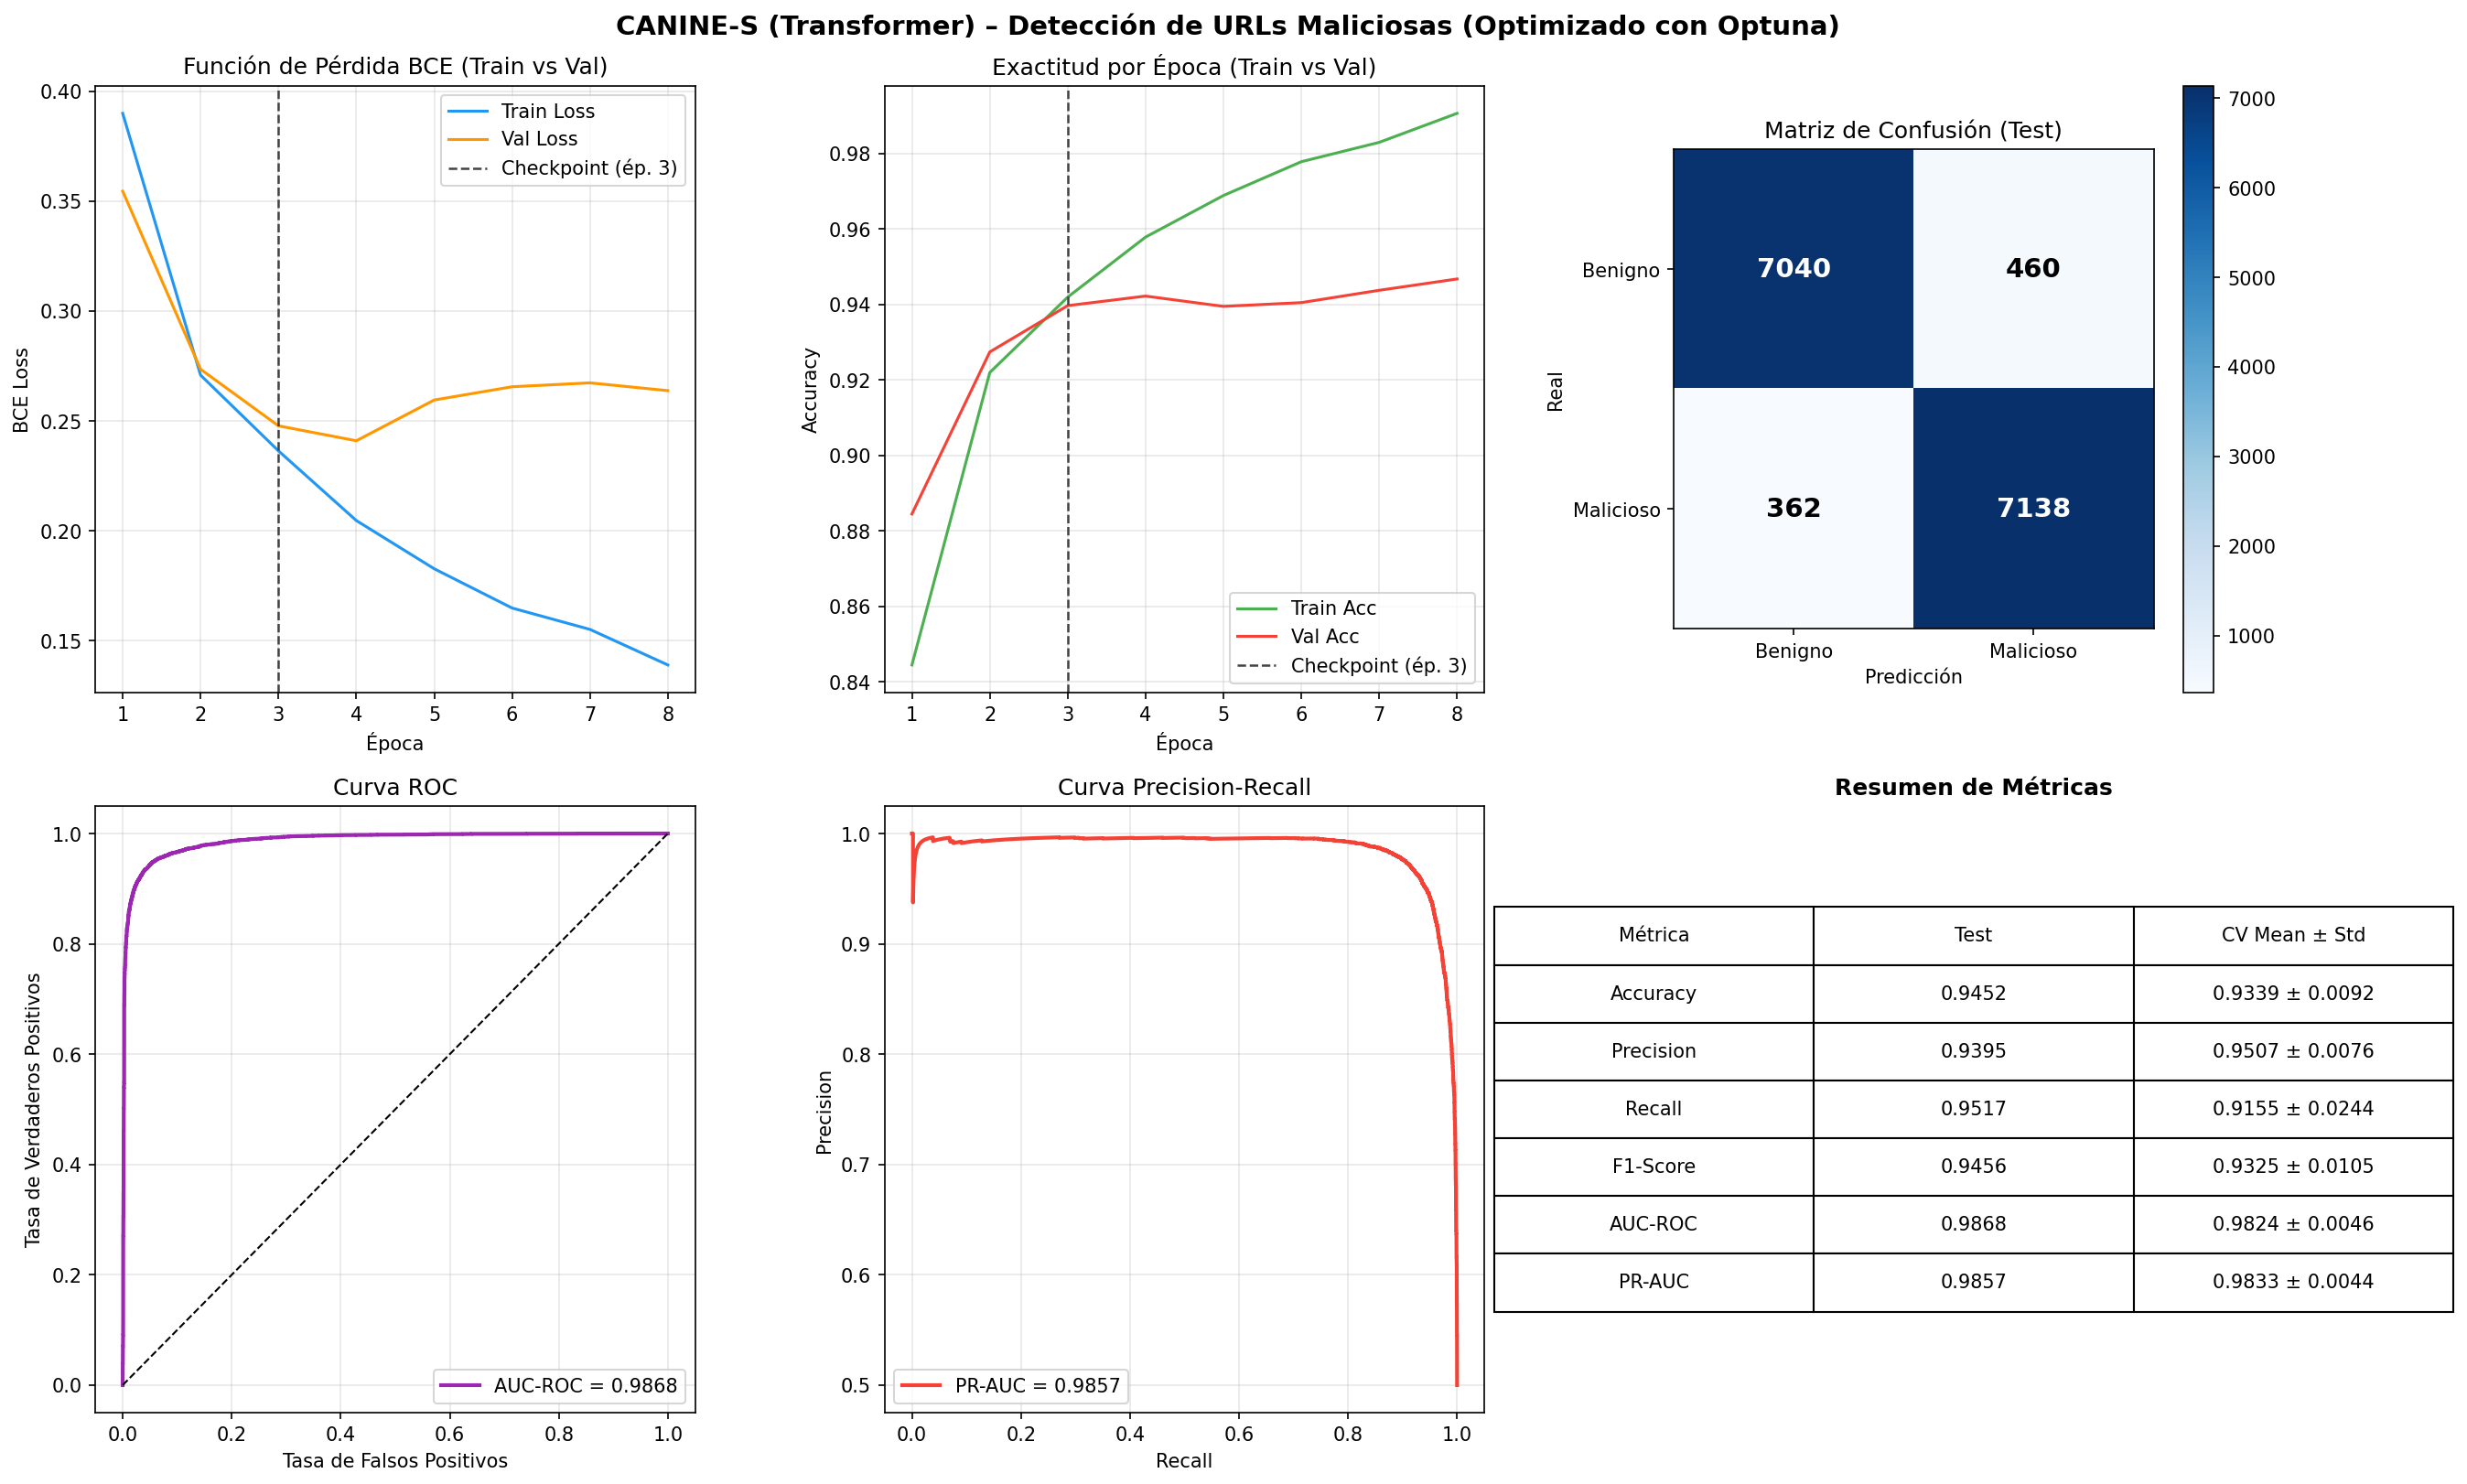


ETAPA 7a – Test Externo LATAM
  [LATAM] URLs con protocolo / www. eliminado: 920 de 3,000 (30.7 %)
  [LATAM] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test LATAM
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test LATAM] ⚠  61 URLs (2.0%) superan MAX_LEN=150 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test LATAM                                 │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.8403                      │
  │  Precisión (Precision)   │  0.8153                      │
  │  Exhaustividad (Recall)  │  0.8800                      │
  │  F1-Score                │  0.8464                      │
  │  AUC-ROC                 │  0.9073                      │
  │  PR-AUC                  │  0.8977                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
              Pr

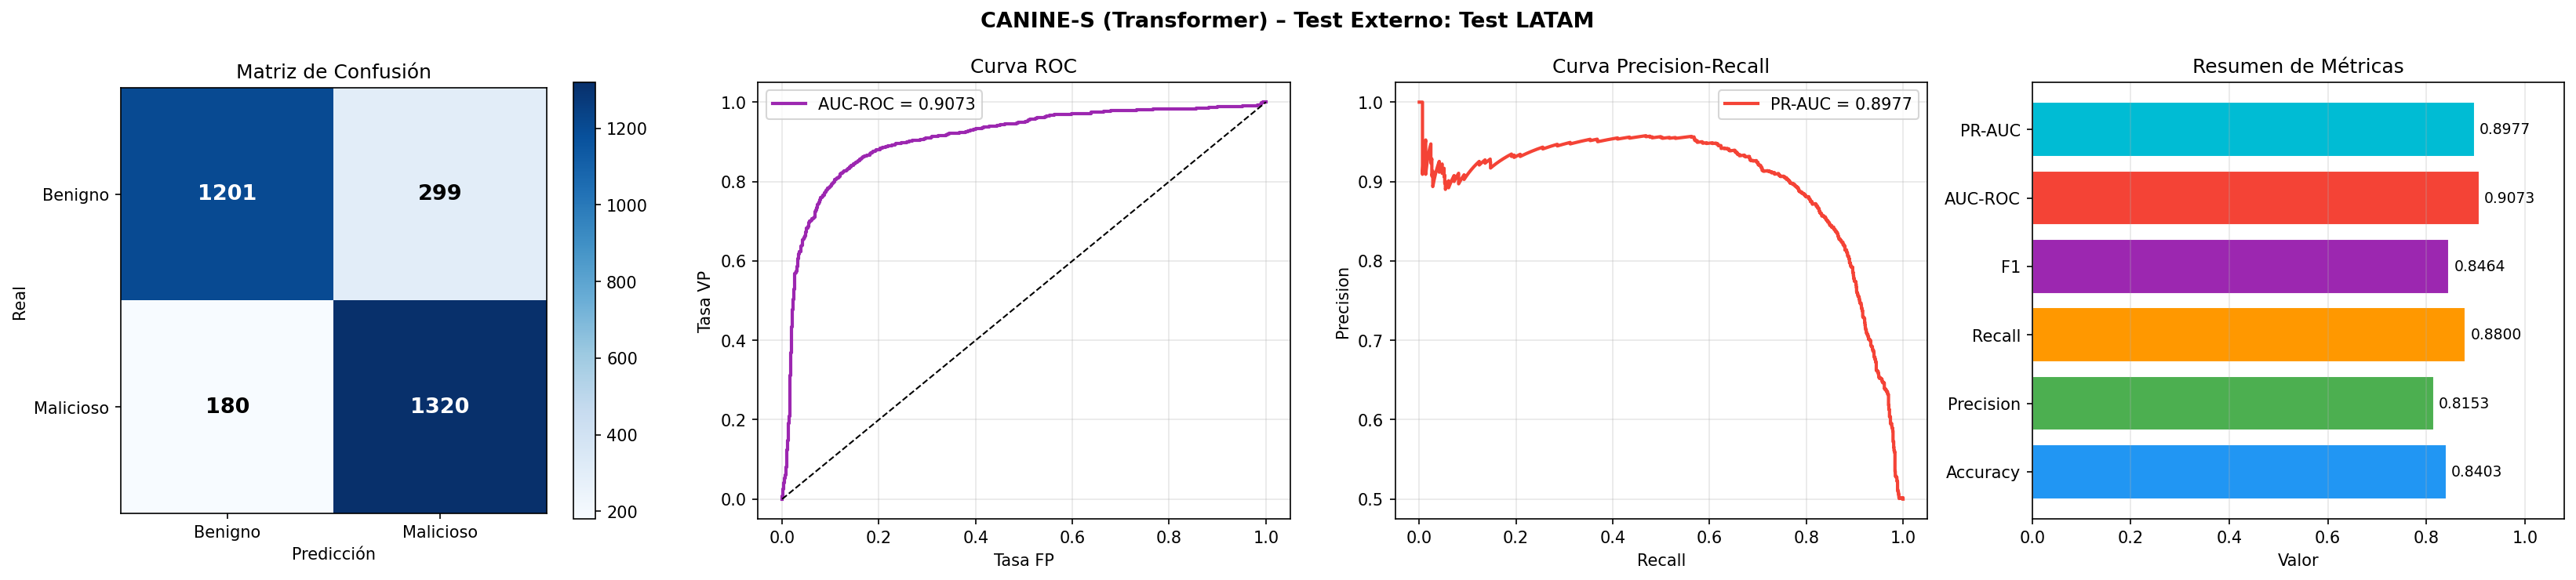


ETAPA 7b – Test Externo Genérico
  [Genérico] URLs con protocolo / www. eliminado: 0 de 3,000 (0.0 %)
  [Genérico] URLs únicas finales: 3,000 / 3,000

  Test Externo – Test Genérico
  Muestras: 3,000  |  Benignas (0): 1,500  |  Maliciosas (1): 1,500
  [Test Genérico] ⚠  87 URLs (2.9%) superan MAX_LEN=150 (se truncan como en train, percentil 95)

  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – Test Genérico                              │
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  0.9533                      │
  │  Precisión (Precision)   │  0.9626                      │
  │  Exhaustividad (Recall)  │  0.9433                      │
  │  F1-Score                │  0.9529                      │
  │  AUC-ROC                 │  0.9919                      │
  │  PR-AUC                  │  0.9904                      │
  └──────────────────────────┴───────────────────────────────┘

  Matriz de Confusión:
    

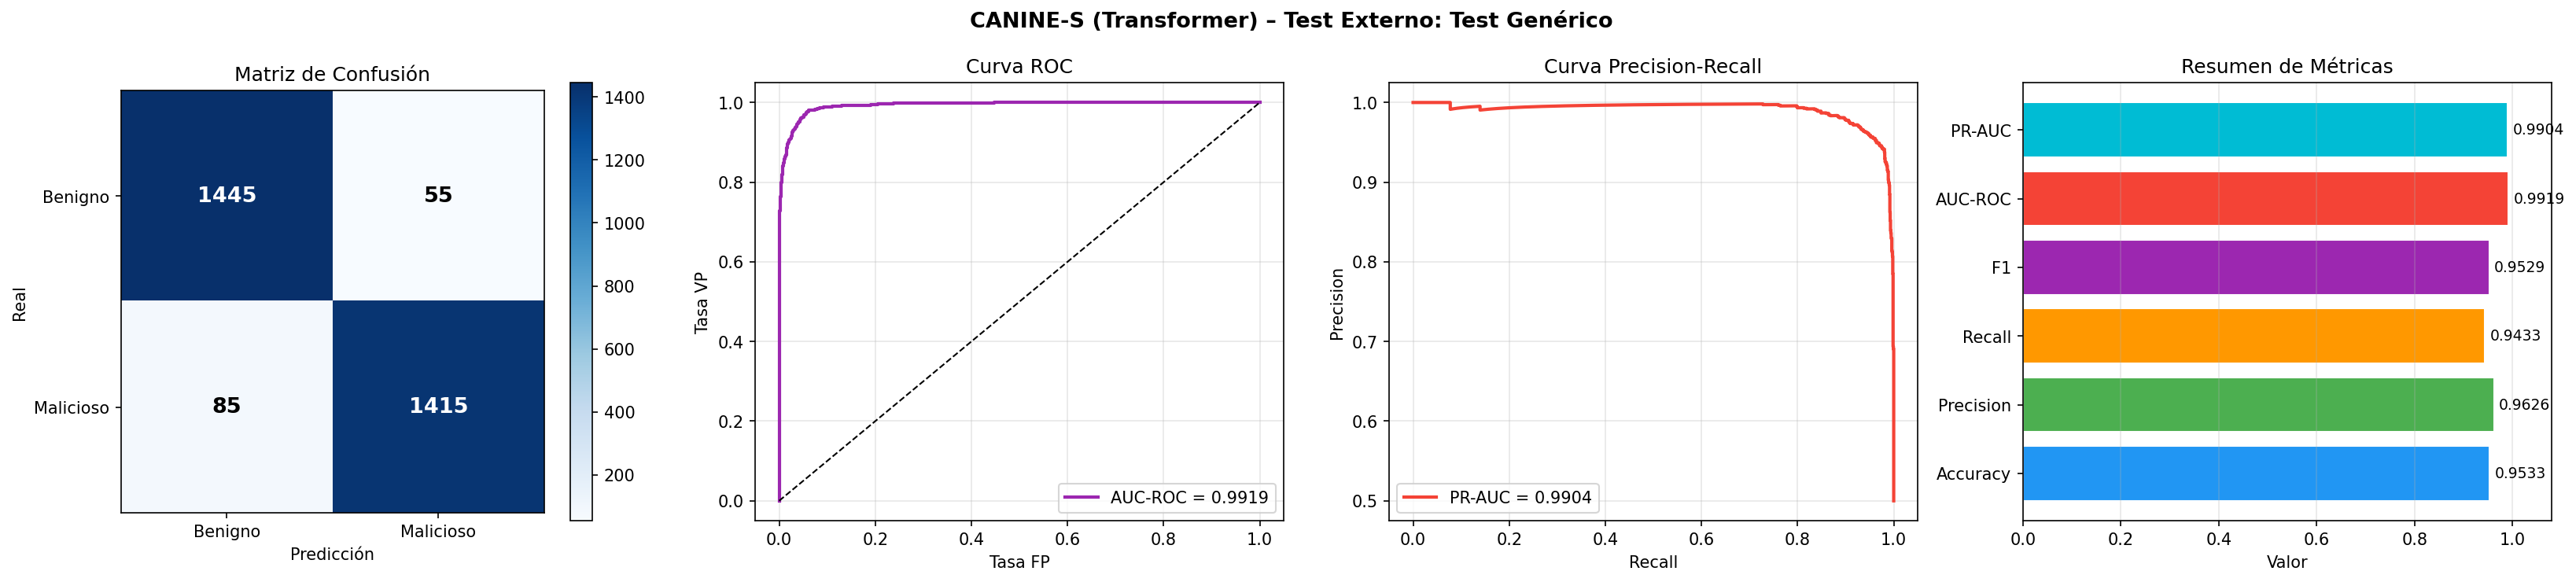


COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico

  Conjunto                       Acc    Prec     Rec      F1   AUC-ROC   PR-AUC
  -----------------------------------------------------------------------------
  Test Interno (15 %)         0.9452  0.9395  0.9517  0.9456    0.9868   0.9857
  Test LATAM (externo)        0.8403  0.8153  0.8800  0.8464    0.9073   0.8977
  Test Genérico (externo)     0.9533  0.9626  0.9433  0.9529    0.9919   0.9904

  ✓ Tabla comparativa guardada: outputs_roberta/roberta_comparacion_tests.csv
  ✓ Gráfica comparativa guardada: outputs_roberta/roberta_comparacion_tests.png


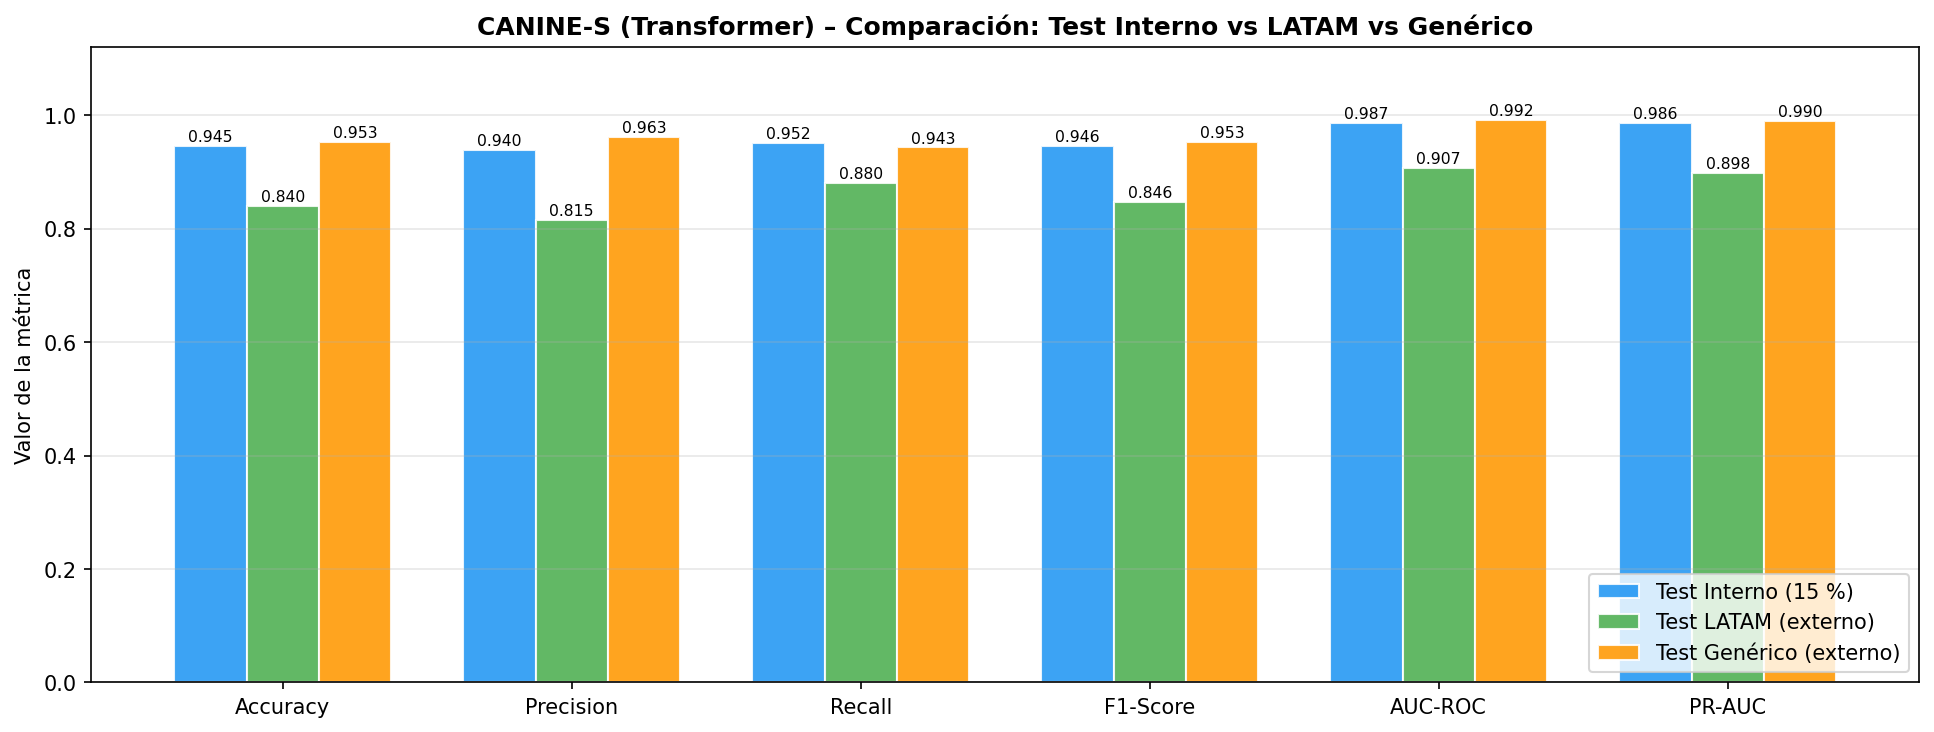


  ✅ Pipeline completo. Todos los resultados en: outputs_roberta


In [ ]:
# =============================================================================
# DETECCIÓN DE URLs MALICIOSAS – CANINE-S (Preentrenado)
# Arquitectura: CANINE-S (Character Transformer)  |  Optuna  |  CV: k=5
#
# NOTA: Se utiliza el modelo preentrenado CANINE-S (Google) basado en
#       caracteres (tokenization-free). La optimización con Optuna, la
#       validación cruzada de 5 pliegues y toda la lógica de evaluación y
#       comparación se mantienen idénticas para garantizar la consistencia.
# =============================================================================

import os
import re
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import optuna
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")
from typing import Optional
from transformers import CanineModel, CanineTokenizer

optuna.logging.set_verbosity(optuna.logging.INFO)

# ---------------------------------------------------------------------------
# CONFIGURACIÓN GENERAL
# ---------------------------------------------------------------------------
SEED       = 42
OUTPUT_DIR = "outputs_roberta"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ► Rutas de los tests externos (ajusta si cambian de ubicación)
EXT_BEN_LATAM = "prueba_latam/benigno_latam_1500.csv"
EXT_MAL_LATAM = "prueba_latam/phishing_latam_1500.csv"
EXT_BEN_GEN   = "prueba_generica/benigno_generico_1500.csv"
EXT_MAL_GEN   = "prueba_generica/phishing_generico_1500.csv"

torch.manual_seed(SEED)
np.random.seed(SEED)


# ---------------------------------------------------------------------------
# UTILIDAD: Limpieza de URL (quitar protocolo)
# ---------------------------------------------------------------------------
_PROTO_RE = re.compile(r'^(?:https?|ftps?)://', re.IGNORECASE)
_WWW_RE   = re.compile(r'^www\.', re.IGNORECASE)

def clean_url(url: str) -> str:
    url = str(url).strip()
    url = _PROTO_RE.sub('', url)
    url = _WWW_RE.sub('', url)
    return url


# ---------------------------------------------------------------------------
# 1. CARGA DE DATOS
# ---------------------------------------------------------------------------
print("=" * 70)
print("ETAPA 1 – Carga del Dataset")
print("=" * 70)

DATA_PATH = "/content/dataset_merged2.csv"

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["url", "label"]).reset_index(drop=True)
df["url"]   = df["url"].astype(str).str.strip()
df          = df[df["url"].str.len() > 0].reset_index(drop=True)
df["url"]   = df["url"].apply(clean_url)
df["label"] = df["label"].astype(int)

labels_unicos = set(df["label"].unique())
assert labels_unicos <= {0, 1}, (
    f"[ETAPA 1] Labels inesperados en dataset_merged: {labels_unicos}. "
    "Solo se admiten 0 (benigno) y 1 (malicioso)."
)

print(f"  Total muestras : {len(df):,}")
print(f"  Benignas (0)   : {(df['label']==0).sum():,}")
print(f"  Maliciosas (1) : {(df['label']==1).sum():,}")
print(f"  Estratos únicos: {df['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 2. STRATIFIED SPLIT POR ESTRATO
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 2 – Stratified Split (70 % Train | 15 % Val | 15 % Test)")
print("         por estrato")
print("=" * 70)

df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['estrato']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['estrato']
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"\n  Estratos únicos – Train: {df_train['estrato'].nunique()} "
      f"| Val: {df_val['estrato'].nunique()} | Test: {df_test['estrato'].nunique()}")


# ---------------------------------------------------------------------------
# 3. PREPROCESAMIENTO – TOKENIZACIÓN Y PADDING CON CANINE-S
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 3 – Tokenización a nivel de carácter con CANINE-S")
print("=" * 70)

tokenizer  = CanineTokenizer.from_pretrained("google/canine-s")
PAD_IDX    = tokenizer.pad_token_id  # 0
VOCAB_SIZE = 1200000  # Rango seguro de caracteres Unicode para la matriz de embeddings dummy

print(f"  Tamaño de vocabulario de caracteres (Unicode): {VOCAB_SIZE}")

lengths = df_train["url"].str.len().values
MAX_LEN = int(np.percentile(lengths, 95))
MAX_LEN = max(MAX_LEN, 150)  # Asegurar una longitud mínima de 150 para evitar truncamiento
MAX_LEN = min(MAX_LEN, 1024) # Tope máximo para evitar OOM en A100 80GB
print(f"  Longitud máxima (ajustada a mínimo 150): {MAX_LEN} caracteres")

print("  Tokenizando splits...")

def tokenize_split(df_split: pd.DataFrame) -> list:
    urls = df_split["url"].tolist()
    encoded = tokenizer(
        urls,
        padding=False,
        truncation=True,
        max_length=MAX_LEN
    )
    return encoded["input_ids"]

X_train = tokenize_split(df_train)
X_val   = tokenize_split(df_val)
X_test  = tokenize_split(df_test)

y_train = df_train["label"].values.astype(np.float32)
y_val   = df_val["label"].values.astype(np.float32)
y_test  = df_test["label"].values.astype(np.float32)

print(f"  X_train len: {len(X_train)} | y_train shape: {y_train.shape}")
print(f"  X_val   len: {len(X_val)}   | y_val   shape: {y_val.shape}")
print(f"  X_test  len: {len(X_test)}  | y_test  shape: {y_test.shape}")

SAMPLE_N = min(5000, len(X_train))

# Generar tokens CSV con padding estático para compatibilidad visual (solo para archivos de muestra)
X_train_sample_padded = [x + [PAD_IDX] * (MAX_LEN - len(x)) if len(x) < MAX_LEN else x[:MAX_LEN] for x in X_train[:SAMPLE_N]]
X_train_sample_arr = np.array(X_train_sample_padded, dtype=np.int32)

token_cols = [f"t{i}" for i in range(MAX_LEN)]
df_tokens  = pd.DataFrame(X_train_sample_arr, columns=token_cols)
df_tokens.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_tokens.insert(1, "label", df_train["label"].values[:SAMPLE_N])
tokens_path = os.path.join(OUTPUT_DIR, "preprocessing_tokens.csv")
df_tokens.to_csv(tokens_path, index=False)
print(f"\n  ✓ Guardado tokens (muestra): {tokens_path}")

EMB_DIM = 64
np.random.seed(SEED)
max_char_id = int(np.max([max(x) if x else 0 for x in X_train[:SAMPLE_N]]))
emb_matrix     = np.random.randn(max_char_id + 1, EMB_DIM).astype(np.float32) * 0.01
url_embeddings = np.array([
    emb_matrix[X_train_sample_arr[i]].mean(axis=0)
    for i in range(SAMPLE_N)
], dtype=np.float32)
emb_cols      = [f"emb_{i}" for i in range(EMB_DIM)]
df_embeddings = pd.DataFrame(url_embeddings, columns=emb_cols)
df_embeddings.insert(0, "url",   df_train["url"].values[:SAMPLE_N])
df_embeddings.insert(1, "label", df_train["label"].values[:SAMPLE_N])
emb_path = os.path.join(OUTPUT_DIR, "preprocessing_embeddings.csv")
df_embeddings.to_csv(emb_path, index=False)
print(f"  ✓ Guardado embeddings (muestra): {emb_path}")

df_padding = pd.DataFrame({
    "url":              df_train["url"].values[:SAMPLE_N],
    "label":            df_train["label"].values[:SAMPLE_N],
    "url_length":       df_train["url"].str.len().values[:SAMPLE_N],
    "padded_length":    MAX_LEN,
    "truncated":        df_train["url"].str.len().values[:SAMPLE_N] > MAX_LEN,
    "pad_tokens_added": np.maximum(
        0, MAX_LEN - df_train["url"].str.len().values[:SAMPLE_N]
    )
})
padding_path = os.path.join(OUTPUT_DIR, "preprocessing_padding.csv")
df_padding.to_csv(padding_path, index=False)
print(f"  ✓ Guardado padding (muestra): {padding_path}")

print(f"\n  Vocab size        : {VOCAB_SIZE}")
print(f"  Emb dim (default) : {EMB_DIM}")
print(f"  Max length        : {MAX_LEN}")


# ---------------------------------------------------------------------------
# 4. DATASET PyTorch Y DEFINICIÓN DEL MODELO TRANSFORMER (estilo RoBERTa)
# ---------------------------------------------------------------------------
class URLDataset(Dataset):
    def __init__(self, X: list, y: np.ndarray):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.long), self.y[idx]

def collate_batch(batch):
    xs, ys = zip(*batch)
    # A100 Opt: Colchón dinámico, rellena solo hasta el máximo de este batch
    xs_padded = torch.nn.utils.rnn.pad_sequence(xs, batch_first=True, padding_value=PAD_IDX)
    ys_tensor = torch.stack(ys)
    return xs_padded, ys_tensor

train_ds = URLDataset(X_train, y_train)
val_ds   = URLDataset(X_val,   y_val)
test_ds  = URLDataset(X_test,  y_test)


# ─────────────────────────────────────────────────────────────────────────────
# CANINE-S (Preentrenado) para clasificación de URLs a nivel de caracteres
#
#   Arquitectura:
#   CanineModel (google/canine-s) preentrenado por Google.
#   → Salida de los embeddings contextuales last_hidden_state de tamaño 768.
#   → Concatenación de Mean Pooling con Máscara y Max Pooling con Máscara.
#   → Dropout → LayerNorm → Linear(768 * 2, 1) para clasificación binaria.
#
#   Ventajas clave:
#   1. Preentrenado sobre una vasta cantidad de datos de texto.
#   2. Nativamente basado en caracteres Unicode (tokenization-free).
#   3. Evita la pérdida del entrenamiento desde cero contra LSTMs.
# ─────────────────────────────────────────────────────────────────────────────

class RoBERTaModel(nn.Module):
    """
    Clase wrapper que mantiene el nombre 'RoBERTaModel' para garantizar compatibilidad
    100% con los scripts de entrenamiento, Optuna y guardado del estado del modelo,
    pero implementa internamente la arquitectura CANINE-S preentrenada.
    """
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int,
                 num_layers: int, dropout: float, pad_idx: int,
                 nhead: int = 4):
        super().__init__()

        # Para mantener compatibilidad con las firmas de inicialización
        self.pad_idx = pad_idx
        self.emb_dim = 768  # El tamaño oculto de CANINE es fijo en 768

        # Cargar el modelo preentrenado CANINE-S
        self.canine = CanineModel.from_pretrained("google/canine-s")

        # Cabezal de clasificación sobre los embeddings de CANINE
        self.layer_norm = nn.LayerNorm(self.emb_dim * 2)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.emb_dim * 2, 1)

    def forward(self, x):
        # x: (B, L) - índices de caracteres (Unicode code points)

        # Crear máscara de atención (1 para tokens reales, 0 para padding)
        attention_mask = (x != self.pad_idx).long()

        # Feedforward a través de CANINE
        outputs = self.canine(input_ids=x, attention_mask=attention_mask)
        out = outputs.last_hidden_state  # (B, L, 768)

        # Crear máscara de padding para pooling
        src_key_padding_mask = (x == self.pad_idx)  # (B, L)
        non_pad_mask = ~src_key_padding_mask
        mask = non_pad_mask.unsqueeze(-1).to(out.dtype)  # (B, L, 1)

        # Pooling de Promedio con Máscara (Masked Mean Pooling)
        sum_embeddings = torch.sum(out * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask  # (B, emb_dim)

        # Pooling de Máximo con Máscara (Masked Max Pooling)
        masked_out = out.masked_fill(src_key_padding_mask.unsqueeze(-1), -1e9)
        max_pooled = masked_out.max(dim=1).values  # (B, emb_dim)

        # Concatenar promedio y máximo para obtener la representación global
        cls_output = torch.cat([mean_pooled, max_pooled], dim=1)  # (B, emb_dim * 2)

        # Cabezal de clasificación final
        cls_output = self.layer_norm(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output).squeeze(1)     # (B,)
        return logits


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n  Dispositivo de cómputo: {DEVICE}")

import torch.nn.functional as F

class SmoothBCEWithLogitsLoss(nn.Module):
    def __init__(self, smoothing=0.05, pos_weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.smoothing = smoothing
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(
            logits, targets_smooth, pos_weight=self.pos_weight
        )


# ---------------------------------------------------------------------------
# Helper: run_epoch
# ---------------------------------------------------------------------------
def run_epoch(loader, model, criterion, optimizer, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            if train:
                optimizer.zero_grad()

            # A100 Opt: Precisión mixta automática BF16
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            preds       = (torch.sigmoid(logits) >= 0.5).long()
            correct    += (preds == y_batch.long()).sum().item()
            total      += len(y_batch)

    return total_loss / total, correct / total


def generalization_score(tr_loss: float, vl_loss: float,
                         tr_acc: float, vl_acc: float,
                         w_loss: float = 1.0, w_acc: float = 0.5) -> float:
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)
    return vl_loss + w_loss * loss_gap + w_acc * acc_gap


# ---------------------------------------------------------------------------
# 5. BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 4 – Búsqueda de Hiperparámetros con Optuna")
print("=" * 70)

def objective(trial):
    # Optimización del espacio de búsqueda para A100 y CANINE-S
    lr           = trial.suggest_float("lr",       2e-5, 1e-4, log=True)
    batch_size   = trial.suggest_categorical("batch_size",   [256, 512, 1024])
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    dropout      = trial.suggest_float("dropout",  0.1, 0.5)

    num_workers_dynamic = min(8, max(1, os.cpu_count() - 1))
    train_loader_opt = DataLoader(train_ds, batch_size=batch_size,
                                  shuffle=True,  num_workers=num_workers_dynamic, pin_memory=True, collate_fn=collate_batch)
    val_loader_opt   = DataLoader(val_ds,   batch_size=batch_size,
                                  shuffle=False, num_workers=num_workers_dynamic, pin_memory=True, collate_fn=collate_batch)

    model_opt = RoBERTaModel(
        vocab_size=VOCAB_SIZE, emb_dim=768, hidden_dim=0, num_layers=0,
        dropout=dropout, pad_idx=PAD_IDX, nhead=0
    ).to(DEVICE)

    # torch.compile apagado para evitar bucles de recompilación por Dynamic Padding
    # model_opt = torch.compile(model_opt)

    criterion_opt = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_opt = torch.optim.AdamW(model_opt.parameters(),
                                      lr=lr, weight_decay=weight_decay)

    # Limitar Optuna a máximo 4 épocas para descarte rápido
    MAX_OPTUNA_EPOCHS = 4
    for epoch in range(MAX_OPTUNA_EPOCHS):
        if epoch < 1:
            warmup_factor = (epoch + 1) / 1.0
            current_lr_opt = lr * warmup_factor
            for param_group in optimizer_opt.param_groups:
                param_group['lr'] = current_lr_opt

        model_opt.train()
        for X_batch, y_batch in train_loader_opt:
            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            optimizer_opt.zero_grad()
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model_opt(X_batch)
                loss   = criterion_opt(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model_opt.parameters(), max_norm=1.0)
            optimizer_opt.step()

        model_opt.eval()
        val_loss, n_samples = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader_opt:
                X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                    logits = model_opt(X_batch)
                    loss   = criterion_opt(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
                n_samples += len(y_batch)

        val_loss /= n_samples
        trial.report(val_loss, epoch)
        if trial.should_prune():
            # Limpieza A100 antes de podar
            del model_opt, optimizer_opt, train_loader_opt, val_loader_opt
            import gc; gc.collect(); torch.cuda.empty_cache()
            raise optuna.exceptions.TrialPruned()

    # Limpieza A100 al finalizar trial exitoso
    del model_opt, optimizer_opt, train_loader_opt, val_loader_opt
    import gc; gc.collect(); torch.cuda.empty_cache()

    return val_loss

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)
print("Iniciando optimización con Optuna (50 trials, TPESampler, Max 4 épocas)...")
study.optimize(objective, n_trials=50)

print("\n🏆 Mejores hiperparámetros encontrados:")
best_params = study.best_params

for k, v in best_params.items():
    print(f"  {k}: {v}")


# ---------------------------------------------------------------------------
# 6. ENTRENAMIENTO FINAL CON MEJORES PARÁMETROS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5 – Entrenamiento Final (70 % Train | 15 % Val | 15 % Test)")
print("=" * 70)

MAX_EPOCHS_FINAL = 50
PATIENCE_ES      = 5
MIN_DELTA_GEN    = 1e-4
GAP_LOSS_WEIGHT  = 1.0
GAP_ACC_WEIGHT   = 0.5

X_final = tokenize_split(df_train)
y_final = df_train["label"].values.astype(np.float32)

final_ds = URLDataset(X_final, y_final)

BEST_BATCH         = best_params["batch_size"]
num_workers_dyn    = min(8, max(1, os.cpu_count() - 1))
final_loader       = DataLoader(final_ds, batch_size=BEST_BATCH,
                                shuffle=True,  num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)
val_monitor_loader = DataLoader(val_ds,   batch_size=BEST_BATCH,
                                shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)
test_loader        = DataLoader(test_ds,  batch_size=BEST_BATCH,
                                shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)

print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f} %)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.1f} %)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f} %)")
print(f"  Épocas máx: {MAX_EPOCHS_FINAL}")
print(f"  Checkpoint: score generalización (val_loss + gap train-val)")
print(f"  EarlyStopping: patience={PATIENCE_ES}, min_delta={MIN_DELTA_GEN}")

best_model = RoBERTaModel(
    vocab_size=VOCAB_SIZE,
    emb_dim=768,
    hidden_dim=0,
    num_layers=0,
    dropout=best_params["dropout"],
    pad_idx=PAD_IDX,
    nhead=0
).to(DEVICE)

# torch.compile apagado para evitar bucles de recompilación por Dynamic Padding
# best_model = torch.compile(best_model)

pos = float((y_final == 1).sum())
neg = float((y_final == 0).sum())
pos_weight = None
if pos > 0 and neg > 0:
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
    print(f"  pos_weight (neg/pos): {pos_weight.item():.4f}")

criterion = SmoothBCEWithLogitsLoss(smoothing=0.05, pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)  # Usar AdamW

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5, min_lr=1e-6
)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "gen_score":  [], "loss_gap": [], "acc_gap":  [],
}

t0 = time.time()
best_gen_score   = float("inf")
best_val_loss    = float("inf")
best_state       = None
best_epoch       = 0
best_val_epoch   = 0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS_FINAL + 1):
    # Warmup lineal de 3 épocas para el entrenamiento final
    if epoch <= 3:
        warmup_factor = epoch / 3.0
        current_lr = best_params["lr"] * warmup_factor
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr

    tr_loss, tr_acc = run_epoch(final_loader,       best_model, criterion,
                                optimizer, train=True)
    vl_loss, vl_acc = run_epoch(val_monitor_loader, best_model, criterion,
                                optimizer, train=False)

    gen_score = generalization_score(
        tr_loss, vl_loss, tr_acc, vl_acc,
        w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
    )
    loss_gap = max(0.0, vl_loss - tr_loss)
    acc_gap  = max(0.0, tr_acc - vl_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["gen_score"].append(gen_score)
    history["loss_gap"].append(loss_gap)
    history["acc_gap"].append(acc_gap)

    # Solo activar el scheduler después de terminar el periodo de warmup
    if epoch > 3:
        scheduler.step(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_val_epoch = epoch

    if gen_score < best_gen_score - MIN_DELTA_GEN:
        best_gen_score = gen_score
        best_epoch     = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in best_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]
        marker = " *" if epoch == best_epoch else ""
        print(f"  Época {epoch:3d}/{MAX_EPOCHS_FINAL}{marker} | "
              f"Loss → Train: {tr_loss:.4f}  Val: {vl_loss:.4f} | "
              f"Acc  → Train: {tr_acc:.4f}  Val: {vl_acc:.4f} | "
              f"Gen: {gen_score:.4f} (gap L/A: {loss_gap:.4f}/{acc_gap:.4f}) | "
              f"LR: {current_lr:.2e} | Tiempo: {elapsed:.1f}s")

    if patience_counter >= PATIENCE_ES:
        print(f"  ⏹ EarlyStopping en época {epoch} "
              f"(mejor generalización: época {best_epoch}, gen={best_gen_score:.4f}).")
        break

if best_state is not None:
    best_model.load_state_dict(best_state)

model_path = os.path.join(OUTPUT_DIR, "roberta_best_optuna_model.pt")
torch.save({k: v.cpu().clone() for k, v in best_model.state_dict().items()}, model_path)

idx = best_epoch - 1
print(f"\n  ✓ Entrenamiento completado")
print(f"  ✓ Época guardada (menor sobreajuste): {best_epoch}")
print(f"      Train loss/acc: {history['train_loss'][idx]:.4f} / {history['train_acc'][idx]:.4f}")
print(f"      Val   loss/acc: {history['val_loss'][idx]:.4f} / {history['val_acc'][idx]:.4f}")
print(f"      Gen score: {best_gen_score:.4f} | gap loss: {history['loss_gap'][idx]:.4f} | "
      f"gap acc: {history['acc_gap'][idx]:.4f}")
if best_val_epoch != best_epoch:
    j = best_val_epoch - 1
    print(f"  ℹ Época con menor val_loss pura: {best_val_epoch} "
          f"(val_loss={history['val_loss'][j]:.4f}, "
          f"train_acc-val_acc={history['acc_gap'][j]:.4f}) — no seleccionada por overfitting")
print(f"  ✓ Modelo guardado en: {model_path}")


# ---------------------------------------------------------------------------
# 7. CROSS-VALIDATION (k=5) CON best_params
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 5.5 – Cross-Validation (k=5) con best_params")
print("=" * 70)

df_cv = pd.concat([df_train, df_val], ignore_index=True)
X_cv  = tokenize_split(df_cv)
y_cv  = df_cv["label"].values.astype(np.float32)

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_cv, df_cv['estrato']), 1):

    X_tr_fold  = [X_cv[i] for i in train_idx]
    y_tr_fold  = y_cv[train_idx]
    X_val_fold = [X_cv[i] for i in val_idx]
    y_val_fold = y_cv[val_idx]

    tr_ds_fold  = URLDataset(X_tr_fold,  y_tr_fold)
    val_ds_fold = URLDataset(X_val_fold, y_val_fold)

    tr_loader_fold  = DataLoader(tr_ds_fold,  batch_size=BEST_BATCH,
                                 shuffle=True,  num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)
    val_loader_fold = DataLoader(val_ds_fold, batch_size=BEST_BATCH,
                                 shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)

    model_cv = RoBERTaModel(
        vocab_size=VOCAB_SIZE,
        emb_dim=768,
        hidden_dim=0,
        num_layers=0,
        dropout=best_params["dropout"],
        pad_idx=PAD_IDX,
        nhead=0
    ).to(DEVICE)

    # torch.compile apagado para evitar bucles de recompilación por Dynamic Padding
    # model_cv = torch.compile(model_cv)

    criterion_cv = SmoothBCEWithLogitsLoss(smoothing=0.05)
    optimizer_cv = torch.optim.AdamW(
        model_cv.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )  # Usar AdamW
    scheduler_cv = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode="min", patience=3, factor=0.3, min_lr=1e-6
    )

    best_cv_gen         = float("inf")
    best_cv_state       = None
    cv_patience_counter = 0
    stop_epoch          = MAX_EPOCHS_FINAL

    for epoch in range(1, MAX_EPOCHS_FINAL + 1):
        # Warmup lineal de 3 épocas para validación cruzada
        if epoch <= 3:
            warmup_factor = epoch / 3.0
            current_lr = best_params["lr"] * warmup_factor
            for param_group in optimizer_cv.param_groups:
                param_group['lr'] = current_lr

        tr_loss_cv, tr_acc_cv = run_epoch(tr_loader_fold,  model_cv, criterion_cv,
                                          optimizer_cv, train=True)
        vl_loss_cv, vl_acc_cv = run_epoch(val_loader_fold, model_cv, criterion_cv,
                                          optimizer_cv, train=False)

        # Solo activar el scheduler después del warmup
        if epoch > 3:
            scheduler_cv.step(vl_loss_cv)

        gen_cv = generalization_score(
            tr_loss_cv, vl_loss_cv, tr_acc_cv, vl_acc_cv,
            w_loss=GAP_LOSS_WEIGHT, w_acc=GAP_ACC_WEIGHT
        )

        if gen_cv < best_cv_gen - MIN_DELTA_GEN:
            best_cv_gen           = gen_cv
            best_cv_state         = {k: v.cpu().clone()
                                     for k, v in model_cv.state_dict().items()}
            cv_patience_counter   = 0
        else:
            cv_patience_counter += 1

        if cv_patience_counter >= PATIENCE_ES:
            stop_epoch = epoch
            break

    model_cv.load_state_dict(best_cv_state)
    model_cv.eval()

    fold_logits, fold_preds, fold_labels = [], [], []
    with torch.no_grad():
        for X_b, y_b in val_loader_fold:
            X_b    = X_b.to(DEVICE, non_blocking=True)
            logits = model_cv(X_b)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            fold_logits.extend(probs.tolist())
            fold_preds.extend(preds.tolist())
            fold_labels.extend(y_b.numpy().tolist())

    y_t       = np.array(fold_labels, dtype=int)
    y_p       = np.array(fold_preds,  dtype=int)
    y_prob_cv = np.array(fold_logits)

    f_acc  = accuracy_score(y_t, y_p)
    f_prec = precision_score(y_t, y_p, zero_division=0)
    f_rec  = recall_score(y_t, y_p,    zero_division=0)
    f_f1   = f1_score(y_t, y_p,        zero_division=0)
    f_roc  = roc_auc_score(y_t, y_prob_cv)
    f_pr   = average_precision_score(y_t, y_prob_cv)

    cv_results.append({
        "fold": fold, "Accuracy": f_acc, "Precision": f_prec,
        "Recall": f_rec, "F1": f_f1, "AUC_ROC": f_roc, "PR_AUC": f_pr
    })

    print(f"  Fold {fold}/5 | F1: {f_f1:.4f} | AUC-ROC: {f_roc:.4f} "
          f"| Época stop: {stop_epoch}")

cv_df       = pd.DataFrame(cv_results)
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
cv_mean     = cv_df[metric_keys].mean()
cv_std      = cv_df[metric_keys].std()

label_map = {
    "Accuracy":  "Accuracy",
    "Precision": "Precision",
    "Recall":    "Recall",
    "F1":        "F1-Score",
    "AUC_ROC":   "AUC-ROC",
    "PR_AUC":    "PR-AUC",
}

print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │          CROSS-VALIDATION – RESULTADOS (k=5)            │
  ├──────────────────────────┬──────────────┬───────────────┤
  │ Métrica                  │     Mean     │      Std      │
  ├──────────────────────────┼──────────────┼───────────────┤""")
for key in metric_keys:
    print(f"  │ {label_map[key]:<24s} │   {cv_mean[key]:.4f}     │  ±{cv_std[key]:.4f}       │")
print("  └──────────────────────────┴──────────────┴───────────────┘")

cv_export = cv_df.copy()
mean_row  = {col: (cv_mean[col] if col in metric_keys else "mean") for col in cv_export.columns}
std_row   = {col: (cv_std[col]  if col in metric_keys else "std")  for col in cv_export.columns}
cv_export = pd.concat(
    [cv_export, pd.DataFrame([mean_row]), pd.DataFrame([std_row])],
    ignore_index=True
)
cv_path = os.path.join(OUTPUT_DIR, "roberta_cv_results.csv")
cv_export.to_csv(cv_path, index=False)
print(f"\n  ✓ Guardado CV results: {cv_path}")


# ---------------------------------------------------------------------------
# 8. EVALUACIÓN EN TEST SET
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("ETAPA 6 – Evaluación en Test Set")
print("=" * 70)

best_model.eval()
all_logits, all_preds, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        logits  = best_model(X_batch)
        probs   = torch.sigmoid(logits).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)
        all_logits.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.numpy().tolist())

y_true  = np.array(all_labels, dtype=int)
y_pred  = np.array(all_preds,  dtype=int)
y_prob  = np.array(all_logits)

acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred,  zero_division=0)
rec     = recall_score(y_true, y_pred,     zero_division=0)
f1      = f1_score(y_true, y_pred,         zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)
cm      = confusion_matrix(y_true, y_pred)

print(f"""
  ┌─────────────────────────────────────────────────────┐
  │   MÉTRICAS DE EVALUACIÓN – CANINE-S (Transformer)   │
  ├──────────────────────────┬──────────────────────────┤
  │  Exactitud (Accuracy)    │  {acc:.4f}                  │
  │  Precisión (Precision)   │  {prec:.4f}                  │
  │  Exhaustividad (Recall)  │  {rec:.4f}                  │
  │  F1-Score                │  {f1:.4f}                  │
  │  AUC-ROC                 │  {roc_auc:.4f}                  │
  │  PR-AUC                  │  {pr_auc:.4f}                  │
  └──────────────────────────┴──────────────────────────┘
""")

print("  Matriz de Confusión:")
print(f"              Pred 0  Pred 1")
print(f"  Real 0  :   {cm[0,0]:6d}  {cm[0,1]:6d}   (TN / FP)")
print(f"  Real 1  :   {cm[1,0]:6d}  {cm[1,1]:6d}   (FN / TP)")
print("\n  Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=["Benigno", "Malicioso"]))


# ---------------------------------------------------------------------------
# 9. GUARDAR MÉTRICAS Y GRÁFICAS
# ---------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "Modelo":    ["CANINE-S"],
    "Best_Epoch": [best_epoch],
    "Accuracy":  [round(acc,     4)],
    "Precision": [round(prec,    4)],
    "Recall":    [round(rec,     4)],
    "F1_Score":  [round(f1,      4)],
    "AUC_ROC":   [round(roc_auc, 4)],
    "PR_AUC":    [round(pr_auc,  4)],
    "TN": [cm[0,0]], "FP": [cm[0,1]],
    "FN": [cm[1,0]], "TP": [cm[1,1]],
})
metrics_path = os.path.join(OUTPUT_DIR, "roberta_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

history_df = pd.DataFrame(history)
history_df.index.name = "epoch"
history_path = os.path.join(OUTPUT_DIR, "roberta_training_history.csv")
history_df.to_csv(history_path)

epochs_ran = len(history["train_loss"])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "CANINE-S (Transformer) – Detección de URLs Maliciosas (Optimizado con Optuna)",
    fontsize=14, fontweight="bold"
)

ax = axes[0, 0]
ax.plot(ep_range, history["train_loss"], label="Train Loss", color="#2196F3")
ax.plot(ep_range, history["val_loss"],   label="Val Loss",   color="#FF9800")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Función de Pérdida BCE (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ep_range, history["train_acc"], label="Train Acc", color="#4CAF50")
ax.plot(ep_range, history["val_acc"],   label="Val Acc",   color="#F44336")
if best_epoch > 0:
    ax.axvline(best_epoch, color="#424242", linestyle="--", linewidth=1.2,
               label=f"Checkpoint (ép. {best_epoch})")
ax.set_title("Exactitud por Época (Train vs Val)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight="bold")
ax.set_title("Matriz de Confusión (Test)")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax.plot(fpr, tpr, color="#9C27B0", lw=2, label=f"AUC-ROC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob)
ax.plot(rec_c, prec_c, color="#F44336", lw=2, label=f"PR-AUC = {pr_auc:.4f}")
ax.set_title("Curva Precision-Recall")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.axis("off")
table_data = [
    ["Métrica",    "Test",           "CV Mean ± Std"],
    ["Accuracy",   f"{acc:.4f}",     f"{cv_mean['Accuracy']:.4f} ± {cv_std['Accuracy']:.4f}"],
    ["Precision",  f"{prec:.4f}",    f"{cv_mean['Precision']:.4f} ± {cv_std['Precision']:.4f}"],
    ["Recall",     f"{rec:.4f}",     f"{cv_mean['Recall']:.4f} ± {cv_std['Recall']:.4f}"],
    ["F1-Score",   f"{f1:.4f}",      f"{cv_mean['F1']:.4f} ± {cv_std['F1']:.4f}"],
    ["AUC-ROC",    f"{roc_auc:.4f}", f"{cv_mean['AUC_ROC']:.4f} ± {cv_std['AUC_ROC']:.4f}"],
    ["PR-AUC",     f"{pr_auc:.4f}",  f"{cv_mean['PR_AUC']:.4f} ± {cv_std['PR_AUC']:.4f}"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.6, 2.2)
ax.set_title("Resumen de Métricas", fontweight="bold")

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "roberta_results_optuna.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close()

print(f"\n  Pipeline completado (test interno). Resultados guardados en: {OUTPUT_DIR}")
display(Image(plot_path))


# ---------------------------------------------------------------------------
# 10. TESTS EXTERNOS
# ---------------------------------------------------------------------------

def load_external_set(path_ben: str, path_mal: str, nombre: str) -> pd.DataFrame:
    df_b = pd.read_csv(path_ben)
    df_m = pd.read_csv(path_mal)

    for d in [df_b, df_m]:
        d.columns = [c.strip().lower() for c in d.columns]

    for d, path in [(df_b, path_ben), (df_m, path_mal)]:
        if "url" not in d.columns:
            raise ValueError(
                f"[{nombre}] No se encontró columna 'url' en '{path}'.\n"
                f"  Columnas disponibles: {d.columns.tolist()}"
            )

    df_b = df_b[["url"]].copy()
    df_m = df_m[["url"]].copy()
    df_b["label"] = 0
    df_m["label"] = 1

    df_ext = pd.concat([df_b, df_m], ignore_index=True)
    df_ext["url"] = df_ext["url"].astype(str).str.strip()
    antes = len(df_ext)
    df_ext = df_ext[df_ext["url"].str.len() > 0].reset_index(drop=True)
    if antes - len(df_ext) > 0:
        print(f"  [{nombre}] ⚠  Se eliminaron {antes - len(df_ext)} filas con URL vacía.")

    urls_originales = df_ext["url"].copy()
    df_ext["url"]   = df_ext["url"].apply(clean_url)

    n_cambiadas = (urls_originales != df_ext["url"]).sum()
    n_ws = urls_originales.str.contains(r"\s", regex=True).sum()
    if n_ws:
        print(f"  [{nombre}] ⚠  URLs con espacios antes de strip: {n_ws}")

    n_dup = df_ext["url"].duplicated().sum()
    if n_dup:
        print(f"  [{nombre}] ⚠  URLs duplicadas tras clean_url: {n_dup} "
              f"(se conserva la primera ocurrencia)")
        df_ext = df_ext.drop_duplicates(subset=["url"], keep="first").reset_index(drop=True)

    print(f"  [{nombre}] URLs con protocolo / www. eliminado: "
          f"{n_cambiadas:,} de {len(df_ext):,} "
          f"({n_cambiadas/len(df_ext)*100:.1f} %)")
    print(f"  [{nombre}] URLs únicas finales: {df_ext['url'].nunique():,} / {len(df_ext):,}")

    assert set(df_ext["label"].unique()) <= {0, 1}
    assert (df_ext["label"] == 0).sum() > 0
    assert (df_ext["label"] == 1).sum() > 0

    return df_ext


def evaluar_externo(df_ext: pd.DataFrame, nombre: str, tag: str) -> dict:
    print(f"\n{'='*70}")
    print(f"  Test Externo – {nombre}")
    print(f"  Muestras: {len(df_ext):,}  |  "
          f"Benignas (0): {(df_ext['label']==0).sum():,}  |  "
          f"Maliciosas (1): {(df_ext['label']==1).sum():,}")
    print(f"{'='*70}")

    n_trunc = (df_ext["url"].str.len() > MAX_LEN).sum()
    if n_trunc:
        pct = n_trunc / len(df_ext) * 100
        print(f"  [{nombre}] ⚠  {n_trunc:,} URLs ({pct:.1f}%) superan MAX_LEN={MAX_LEN} "
              f"(se truncan como en train, percentil 95)")

    X_ext = tokenize_split(df_ext)
    y_ext = df_ext["label"].values.astype(np.float32)

    ext_ds     = URLDataset(X_ext, y_ext)
    ext_loader = DataLoader(ext_ds, batch_size=BEST_BATCH,
                            shuffle=False, num_workers=num_workers_dyn, pin_memory=True, collate_fn=collate_batch)

    best_model.eval()
    ext_logits, ext_preds, ext_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in ext_loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            logits  = best_model(X_batch)
            probs   = torch.sigmoid(logits).cpu().numpy()
            preds   = (probs >= 0.5).astype(int)
            ext_logits.extend(probs.tolist())
            ext_preds.extend(preds.tolist())
            ext_labels.extend(y_batch.numpy().tolist())

    yt    = np.array(ext_labels, dtype=int)
    yp    = np.array(ext_preds,  dtype=int)
    yprob = np.array(ext_logits)

    e_acc  = accuracy_score(yt, yp)
    e_prec = precision_score(yt, yp, zero_division=0)
    e_rec  = recall_score(yt, yp,    zero_division=0)
    e_f1   = f1_score(yt, yp,        zero_division=0)
    e_roc  = roc_auc_score(yt, yprob)
    e_pr   = average_precision_score(yt, yprob)
    e_cm   = confusion_matrix(yt, yp)

    print(f"""
  ┌──────────────────────────────────────────────────────────┐
  │   MÉTRICAS – {nombre:<43s}│
  ├──────────────────────────┬───────────────────────────────┤
  │  Exactitud (Accuracy)    │  {e_acc:.4f}                      │
  │  Precisión (Precision)   │  {e_prec:.4f}                      │
  │  Exhaustividad (Recall)  │  {e_rec:.4f}                      │
  │  F1-Score                │  {e_f1:.4f}                      │
  │  AUC-ROC                 │  {e_roc:.4f}                      │
  │  PR-AUC                  │  {e_pr:.4f}                      │
  └──────────────────────────┴───────────────────────────────┘
""")

    print("  Matriz de Confusión:")
    print(f"              Pred 0  Pred 1")
    print(f"  Real 0  :   {e_cm[0,0]:6d}  {e_cm[0,1]:6d}   (TN / FP)")
    print(f"  Real 1  :   {e_cm[1,0]:6d}  {e_cm[1,1]:6d}   (FN / TP)")
    print("\n  Reporte de Clasificación:")
    print(classification_report(yt, yp, target_names=["Benigno", "Malicioso"]))

    metrics_ext = pd.DataFrame({
        "Modelo":    [f"CANINE-S_{tag}"],
        "Accuracy":  [round(e_acc,  4)],
        "Precision": [round(e_prec, 4)],
        "Recall":    [round(e_rec,  4)],
        "F1_Score":  [round(e_f1,   4)],
        "AUC_ROC":   [round(e_roc,  4)],
        "PR_AUC":    [round(e_pr,   4)],
        "TN": [e_cm[0,0]], "FP": [e_cm[0,1]],
        "FN": [e_cm[1,0]], "TP": [e_cm[1,1]],
    })
    csv_path = os.path.join(OUTPUT_DIR, f"roberta_metrics_ext_{tag}.csv")
    metrics_ext.to_csv(csv_path, index=False)
    print(f"  ✓ Métricas guardadas: {csv_path}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(
        f"CANINE-S (Transformer) – Test Externo: {nombre}",
        fontsize=13, fontweight="bold"
    )

    ax = axes[0]
    im = ax.imshow(e_cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benigno", "Malicioso"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benigno", "Malicioso"])
    thresh = e_cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(e_cm[i, j]), ha="center", va="center",
                    color="white" if e_cm[i, j] > thresh else "black",
                    fontsize=13, fontweight="bold")
    ax.set_title("Matriz de Confusión")
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

    ax = axes[1]
    fpr_e, tpr_e, _ = roc_curve(yt, yprob)
    ax.plot(fpr_e, tpr_e, color="#9C27B0", lw=2,
            label=f"AUC-ROC = {e_roc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("Curva ROC")
    ax.set_xlabel("Tasa FP"); ax.set_ylabel("Tasa VP")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2]
    prec_e, rec_e, _ = precision_recall_curve(yt, yprob)
    ax.plot(rec_e, prec_e, color="#F44336", lw=2,
            label=f"PR-AUC = {e_pr:.4f}")
    ax.set_title("Curva Precision-Recall")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[3]
    met_names = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "PR-AUC"]
    met_vals  = [e_acc, e_prec, e_rec, e_f1, e_roc, e_pr]
    colors    = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#00BCD4"]
    bars = ax.barh(met_names, met_vals, color=colors, edgecolor="white")
    ax.set_xlim(0, 1.08)
    for bar, val in zip(bars, met_vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_title("Resumen de Métricas")
    ax.set_xlabel("Valor")
    ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    png_path = os.path.join(OUTPUT_DIR, f"roberta_results_ext_{tag}.png")
    plt.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✓ Gráfica guardada:  {png_path}")
    display(Image(png_path))

    return {
        "nombre": nombre, "tag": tag,
        "Accuracy": e_acc, "Precision": e_prec, "Recall": e_rec,
        "F1": e_f1, "AUC_ROC": e_roc, "PR_AUC": e_pr,
        "TN": e_cm[0,0], "FP": e_cm[0,1],
        "FN": e_cm[1,0], "TP": e_cm[1,1],
    }


print("\n" + "=" * 70)
print("ETAPA 7a – Test Externo LATAM")
print("=" * 70)

df_ext_latam = load_external_set(EXT_BEN_LATAM, EXT_MAL_LATAM, "LATAM")
res_latam    = evaluar_externo(df_ext_latam, "Test LATAM", "latam")

print("\n" + "=" * 70)
print("ETAPA 7b – Test Externo Genérico")
print("=" * 70)

df_ext_gen = load_external_set(EXT_BEN_GEN, EXT_MAL_GEN, "Genérico")
res_gen    = evaluar_externo(df_ext_gen, "Test Genérico", "generico")


print("\n" + "=" * 70)
print("COMPARACIÓN FINAL – Test Interno | Test LATAM | Test Genérico")
print("=" * 70)

comp_df = pd.DataFrame([
    {
        "Conjunto":  "Test Interno (15 %)",
        "Accuracy":  round(acc,     4),
        "Precision": round(prec,    4),
        "Recall":    round(rec,     4),
        "F1":        round(f1,      4),
        "AUC_ROC":   round(roc_auc, 4),
        "PR_AUC":    round(pr_auc,  4),
    },
    {
        "Conjunto":  "Test LATAM (externo)",
        "Accuracy":  round(res_latam["Accuracy"],  4),
        "Precision": round(res_latam["Precision"], 4),
        "Recall":    round(res_latam["Recall"],    4),
        "F1":        round(res_latam["F1"],        4),
        "AUC_ROC":   round(res_latam["AUC_ROC"],   4),
        "PR_AUC":    round(res_latam["PR_AUC"],    4),
    },
    {
        "Conjunto":  "Test Genérico (externo)",
        "Accuracy":  round(res_gen["Accuracy"],  4),
        "Precision": round(res_gen["Precision"], 4),
        "Recall":    round(res_gen["Recall"],    4),
        "F1":        round(res_gen["F1"],        4),
        "AUC_ROC":   round(res_gen["AUC_ROC"],   4),
        "PR_AUC":    round(res_gen["PR_AUC"],    4),
    },
])

header = f"{'Conjunto':<26} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC-ROC':>9} {'PR-AUC':>8}"
print(f"\n  {header}")
print("  " + "-" * len(header))
for _, row in comp_df.iterrows():
    print(f"  {row['Conjunto']:<26} "
          f"{row['Accuracy']:>7.4f} {row['Precision']:>7.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} "
          f"{row['AUC_ROC']:>9.4f} {row['PR_AUC']:>8.4f}")

comp_path = os.path.join(OUTPUT_DIR, "roberta_comparacion_tests.csv")
comp_df.to_csv(comp_path, index=False)
print(f"\n  ✓ Tabla comparativa guardada: {comp_path}")

fig, ax = plt.subplots(figsize=(13, 5))
metricas_comp = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC", "PR_AUC"]
labels_comp   = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "PR-AUC"]
x      = np.arange(len(metricas_comp))
width  = 0.25
colores_comp = ["#2196F3", "#4CAF50", "#FF9800"]

for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metricas_comp]
    bars = ax.bar(x + i * width, vals, width,
                  label=row["Conjunto"], color=colores_comp[i],
                  edgecolor="white", alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(labels_comp)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("CANINE-S (Transformer) – Comparación: Test Interno vs LATAM vs Genérico",
             fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
comp_plot_path = os.path.join(OUTPUT_DIR, "roberta_comparacion_tests.png")
plt.savefig(comp_plot_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"  ✓ Gráfica comparativa guardada: {comp_plot_path}")
display(Image(comp_plot_path))

print(f"\n  ✅ Pipeline completo. Todos los resultados en: {OUTPUT_DIR}")